# Segmentation Assignment with Movie Theater Clusters
By Julia Reich with help from Dr. Pekgun
02.19.2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Load Data and check for missing values

In [2]:
# load the data into a pandas dataframe

data_path = 'survey_responses.csv'
df1 = pd.read_csv(data_path)

# preview data
df1.info()
df1.head
print(df1)

# total count of NaN values
print(df1.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Music                       1007 non-null   float64
 1   Slow songs or fast songs    1008 non-null   float64
 2   Dance                       1006 non-null   float64
 3   Folk                        1005 non-null   float64
 4   Country                     1005 non-null   float64
 5   Classical music             1003 non-null   float64
 6   Musical                     1008 non-null   float64
 7   Pop                         1007 non-null   float64
 8   Rock                        1004 non-null   float64
 9   Metal or Hardrock           1007 non-null   float64
 10  Punk                        1002 non-null   float64
 11  Hiphop, Rap                 1006 non-null   float64
 12  Horror                      1008 non-null   float64
 13  Thriller                    1009 

# Preprocess Data


*   Drop unnecessary variables
*   Convert categorical variables to numeric



In [3]:
# drop null values
df = df1.dropna()
df = pd.get_dummies(df, columns=['Alcohol','Gender'])

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 855 entries, 1 to 1009
Data columns (total 55 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Music                       855 non-null    float64
 1   Slow songs or fast songs    855 non-null    float64
 2   Dance                       855 non-null    float64
 3   Folk                        855 non-null    float64
 4   Country                     855 non-null    float64
 5   Classical music             855 non-null    float64
 6   Musical                     855 non-null    float64
 7   Pop                         855 non-null    float64
 8   Rock                        855 non-null    float64
 9   Metal or Hardrock           855 non-null    float64
 10  Punk                        855 non-null    float64
 11  Hiphop, Rap                 855 non-null    float64
 12  Horror                      855 non-null    float64
 13  Thriller                    855 non-nul

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Entertainment spending,Spending on looks,Spending on gadgets,Spending on healthy eating,Age,Alcohol_drink a lot,Alcohol_never,Alcohol_social drinker,Gender_female,Gender_male
1,4.0,3.0,3.0,2.0,2.0,2.0,3.0,3.0,2.0,1.0,...,3.0,3.0,3,3.0,16.0,False,True,False,True,False
2,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,4.0,...,4.0,5.0,5,5.0,22.0,True,False,False,False,True
3,5.0,3.0,1.0,1.0,1.0,1.0,1.0,2.0,4.0,5.0,...,5.0,1.0,4,1.0,19.0,True,False,False,False,True
5,3.0,3.0,3.0,3.0,2.0,5.0,4.0,3.0,3.0,1.0,...,4.0,3.0,1,3.0,19.0,False,False,True,True,False
6,5.0,4.0,3.0,1.0,1.0,2.0,3.0,3.0,5.0,5.0,...,3.0,4.0,4,3.0,19.0,False,False,True,True,False


# Standardize Data using StandardScaler

In [4]:
#Standardize Data
dfcolumns = df.columns.values.tolist()

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df.to_numpy())
df_scaled = pd.DataFrame(df_scaled, columns=dfcolumns)


df_scaled.head()

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Entertainment spending,Spending on looks,Spending on gadgets,Spending on healthy eating,Age,Alcohol_drink a lot,Alcohol_never,Alcohol_social drinker,Gender_female,Gender_male
0,-1.136086,-0.389808,-0.076076,-0.259134,-0.118289,-0.786908,0.175185,-0.398955,-1.529334,-0.996015,...,-0.182384,-0.094995,0.092316,-0.512061,-1.581936,-0.538138,2.702031,-1.37779,0.824478,-0.824478
1,-4.195468,-0.389808,-0.931935,-0.259134,-0.118289,-0.786908,-0.613147,-1.262517,0.185526,1.176416,...,0.665109,1.562564,1.639973,1.347014,0.567251,1.858259,-0.370092,-1.37779,-1.212888,1.212888
2,0.393605,-0.389808,-1.787794,-1.141843,-1.046156,-1.587868,-1.401478,-1.262517,0.185526,1.900560,...,1.512602,-1.752554,0.866145,-2.371137,-0.507342,1.858259,-0.370092,-1.37779,-1.212888,1.212888
3,-2.665777,-0.389808,-0.076076,0.623574,-0.118289,1.615972,0.963516,-0.398955,-0.671904,-0.996015,...,0.665109,-0.094995,-1.455340,-0.512061,-0.507342,-0.538138,-0.370092,0.72580,0.824478,-0.824478
4,0.393605,0.835508,-0.076076,-1.141843,-1.046156,-0.786908,0.175185,-0.398955,1.042956,1.900560,...,-0.182384,0.733785,0.866145,-0.512061,-0.507342,-0.538138,-0.370092,0.72580,0.824478,-0.824478


#How Many Clusters
Create an Elbow plot to provide guidance on how many clusters might be needed

  File "C:\Users\jemre\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\jemre\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jemre\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jemre\anaconda3\Lib\subprocess.

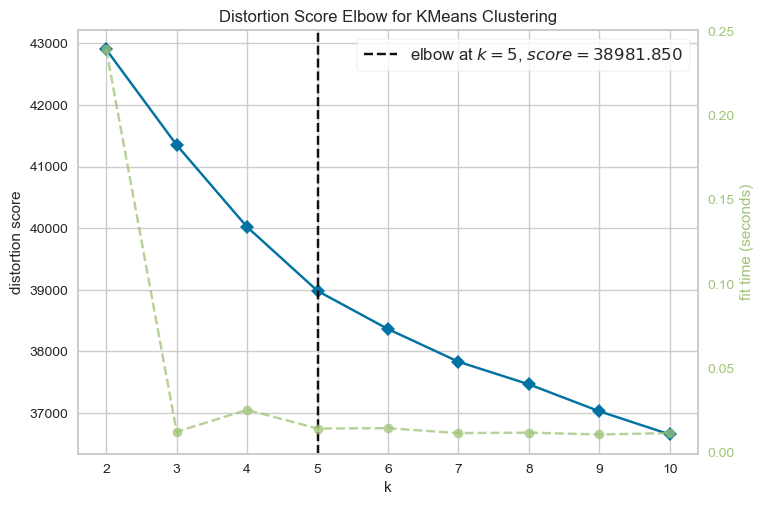

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [5]:
# set the model type to k-means
model = KMeans(random_state=904)

k_values = range(2, 11)

# generate an elbow plot for k = 2 to 10 clusters using the scaled data
visualizer = KElbowVisualizer(model, k=k_values)
visualizer.fit(df_scaled)
visualizer.show()

In [6]:
inertia = []
silhouette = []

n = df_scaled.shape[0]

for i in k_values:
    km = KMeans(n_clusters=i, random_state=904).fit(df_scaled)
    labels = km.fit_predict(df_scaled)
    inertia.append(km.inertia_)                 # WCSS
    silhouette.append(silhouette_score(df_scaled, km.labels_))  #silhouette score

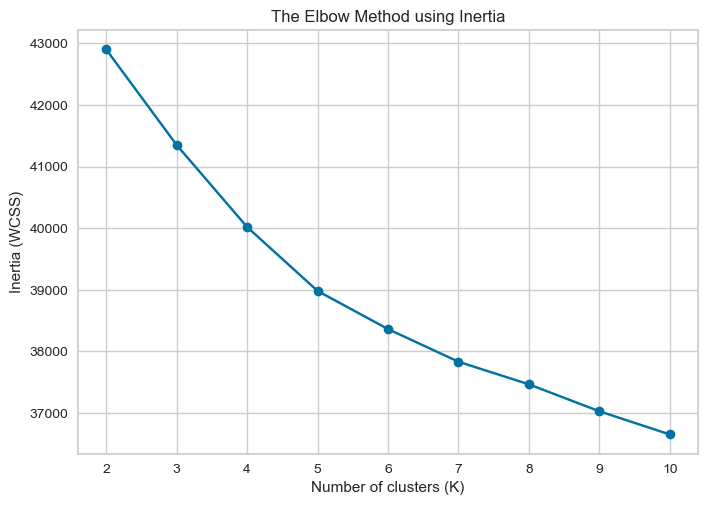

In [7]:
plt.figure()
plt.plot(k_values, inertia, marker="o", label="Inertia (WCSS)")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title('The Elbow Method using Inertia')
plt.show()

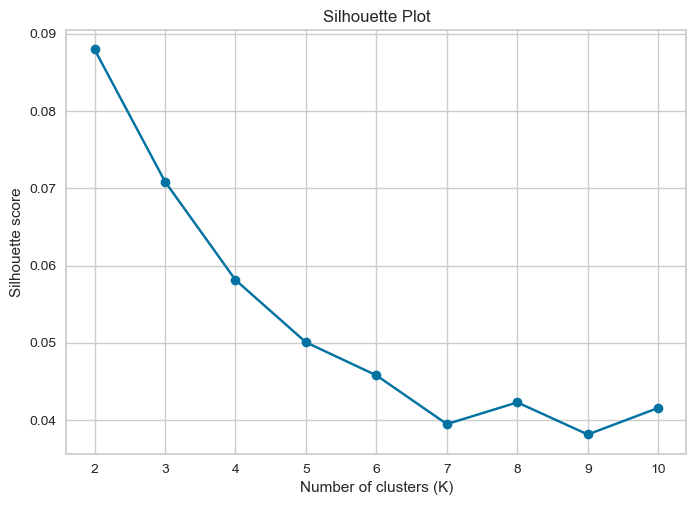

In [8]:
plt.figure()
plt.plot(k_values, silhouette, marker="o", label="Silhouette score")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title('Silhouette Plot')
plt.show()

#Generate Clusters and Begin Profiling
- Evaluate cluster sizes
- Compute the mean of each input variable within each cluster

<class 'pandas.core.frame.DataFrame'>
Index: 855 entries, 1 to 1009
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Music                       855 non-null    float64
 1   Slow songs or fast songs    855 non-null    float64
 2   Dance                       855 non-null    float64
 3   Folk                        855 non-null    float64
 4   Country                     855 non-null    float64
 5   Classical music             855 non-null    float64
 6   Musical                     855 non-null    float64
 7   Pop                         855 non-null    float64
 8   Rock                        855 non-null    float64
 9   Metal or Hardrock           855 non-null    float64
 10  Punk                        855 non-null    float64
 11  Hiphop, Rap                 855 non-null    float64
 12  Horror                      855 non-null    float64
 13  Thriller                    855 non-nul

Text(0.5, 1.0, 'Customer Segmentation by 5 clusters')

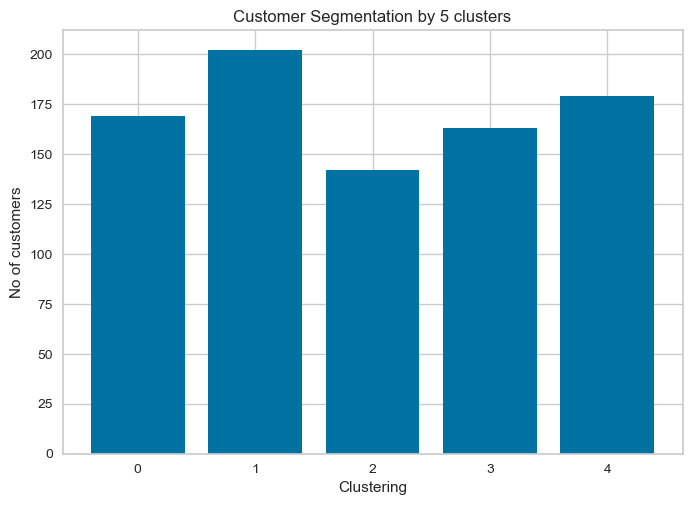

In [9]:
# Based on the above analysis, define the desired value of K here
K = 5

# Create an instance of KMeans with the desired value of K and fit to the scaled data
kmeans = KMeans(n_clusters=K, random_state=904)
kmclus=kmeans.fit(df_scaled)

clusters = kmeans.fit_predict(df_scaled)

# Append cluster to original data
df['cluster']=clusters
df.info()

# Examine the means of each variable by cluster
print("\n The Means of Each Variable by Cluster")
df_desc = df.groupby('cluster').mean()
print(df_desc.round(3))

# Evaluate cluster sizes to ensure that they are similar
print("\n Number of Data Points by Cluster")
print(df['cluster'].value_counts())

# Plot the number of observations in each cluster as a bar chart
n_cluster, km_count = np.unique(clusters, return_counts=True)
plt.bar(n_cluster, km_count)
plt.ylabel('No of customers')
plt.xlabel('Clustering')
plt.title(f'Customer Segmentation by {K} clusters')

In [19]:
# Examine the means of each variable by cluster
df_means = df_desc.round(3)

# Temporarily set display options to show all columns
pd.set_option('display.max_columns', None)

# Display the entire df_means DataFrame
display(df_means)

# Reset display options to their defaults
pd.reset_option('display.max_columns')

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,Punk,"Hiphop, Rap",Horror,Thriller,Comedy,Romantic,Sci-fi,War,Fantasy/Fairy tales,Animated,Documentary,Western,Action,History,Cars,Art exhibitions,Religion,"Countryside, outdoors",Dancing,Musical instruments,Writing,Passive sport,Active sport,Gardening,Celebrities,Shopping,Science and technology,Theatre,Fun with friends,Adrenaline sports,Number of friends,Socializing,Life struggles,Shopping centres,Branded clothing,Entertainment spending,Spending on looks,Spending on gadgets,Spending on healthy eating,Age,Alcohol_drink a lot,Alcohol_never,Alcohol_social drinker,Gender_female,Gender_male
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,4.598,3.521,3.402,1.716,1.840,2.402,2.065,3.515,3.391,1.970,2.095,3.704,3.308,3.698,4.627,2.893,3.408,3.740,3.154,3.320,3.544,2.467,4.325,2.994,3.763,1.870,1.763,3.219,1.882,1.781,1.402,3.858,4.089,1.503,2.243,3.000,3.680,2.183,4.710,3.580,3.568,3.254,2.077,3.438,3.840,3.793,3.497,3.787,3.704,20.515,0.308,0.130,0.562,0.030,0.970
1,4.842,3.406,3.624,1.906,1.693,2.361,2.921,4.084,3.307,1.604,1.980,3.401,2.748,3.277,4.787,4.188,2.594,2.470,4.059,3.921,2.955,1.455,3.074,2.718,2.297,2.450,1.832,3.515,3.059,1.881,1.718,3.376,3.129,1.995,3.248,4.396,2.629,3.089,4.777,2.851,3.604,3.470,3.688,4.168,3.302,3.238,3.762,2.817,3.673,19.946,0.163,0.084,0.752,0.985,0.015
2,4.894,3.268,3.338,3.106,2.796,3.845,3.676,3.676,4.232,2.613,2.859,2.810,2.803,3.331,4.599,4.211,3.472,3.373,4.415,4.387,4.085,2.465,3.563,3.711,2.662,3.620,2.894,4.254,3.486,3.401,2.746,3.585,3.810,2.613,2.479,3.782,3.634,4.085,4.746,3.500,3.655,3.430,3.570,3.620,3.092,3.493,3.521,3.000,3.775,20.324,0.282,0.134,0.585,0.817,0.183
3,4.755,3.331,2.528,2.497,2.479,3.380,2.405,2.840,4.337,3.528,3.178,2.368,2.853,3.706,4.209,2.650,3.791,3.957,3.202,3.405,4.006,2.706,3.939,3.656,2.975,2.337,2.466,3.620,1.632,2.620,1.890,3.436,3.184,1.558,1.583,2.129,3.853,2.515,4.405,2.847,3.031,2.890,2.006,2.387,2.718,3.074,2.221,2.779,3.313,20.920,0.258,0.153,0.589,0.080,0.920
4,4.637,3.056,2.503,2.447,2.039,3.184,2.916,3.106,3.832,2.391,2.324,1.944,2.196,2.894,4.229,3.475,2.475,2.497,3.927,3.916,3.804,1.715,2.810,3.123,1.676,2.827,2.486,3.804,2.140,2.307,1.877,2.804,2.296,1.922,1.983,2.888,2.682,3.374,4.190,1.972,2.849,2.709,3.732,2.620,2.335,2.553,2.514,2.095,3.307,20.469,0.140,0.112,0.749,0.983,0.017


# Profile Clusters

## Survey Responses: Movie Preferences

### Thriller Movies

<Figure size 800x400 with 0 Axes>

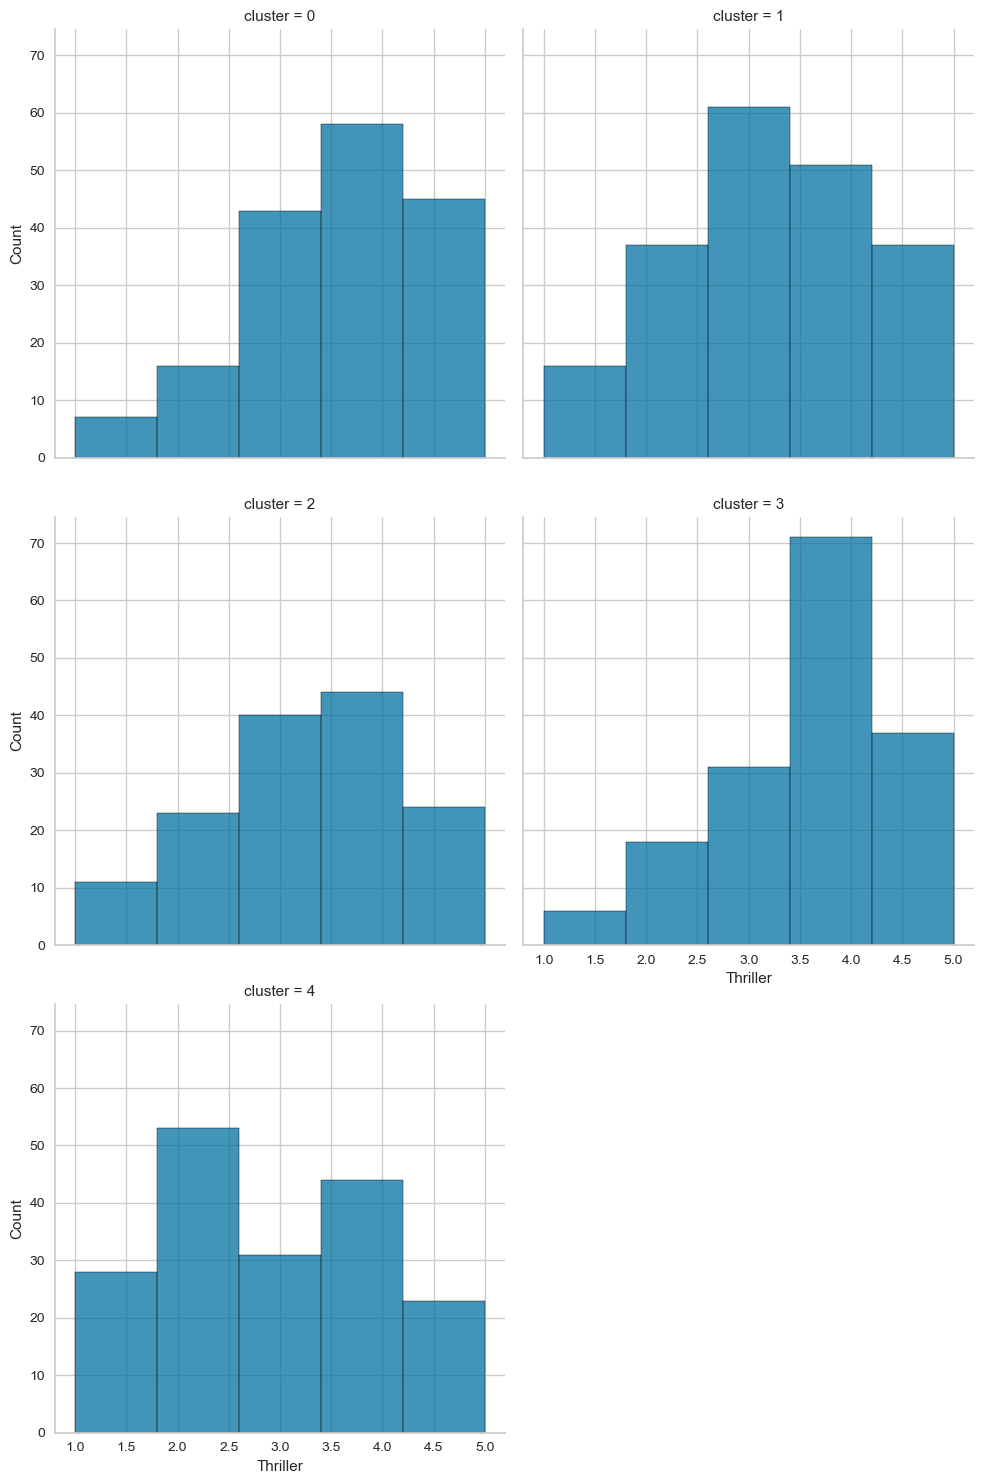

In [24]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Thriller", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [25]:
dfrom = df[['Thriller', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Thriller                                             
           count      mean       std  min  25%  50%  75%  max
cluster                                                      
0          169.0  3.698225  1.090024  1.0  3.0  4.0  5.0  5.0
1          202.0  3.277228  1.189664  1.0  2.0  3.0  4.0  5.0
2          142.0  3.330986  1.165228  1.0  3.0  3.0  4.0  5.0
3          163.0  3.705521  1.053697  1.0  3.0  4.0  4.0  5.0
4          179.0  2.893855  1.296025  1.0  2.0  3.0  4.0  5.0


### Horror Movies

<Figure size 800x400 with 0 Axes>

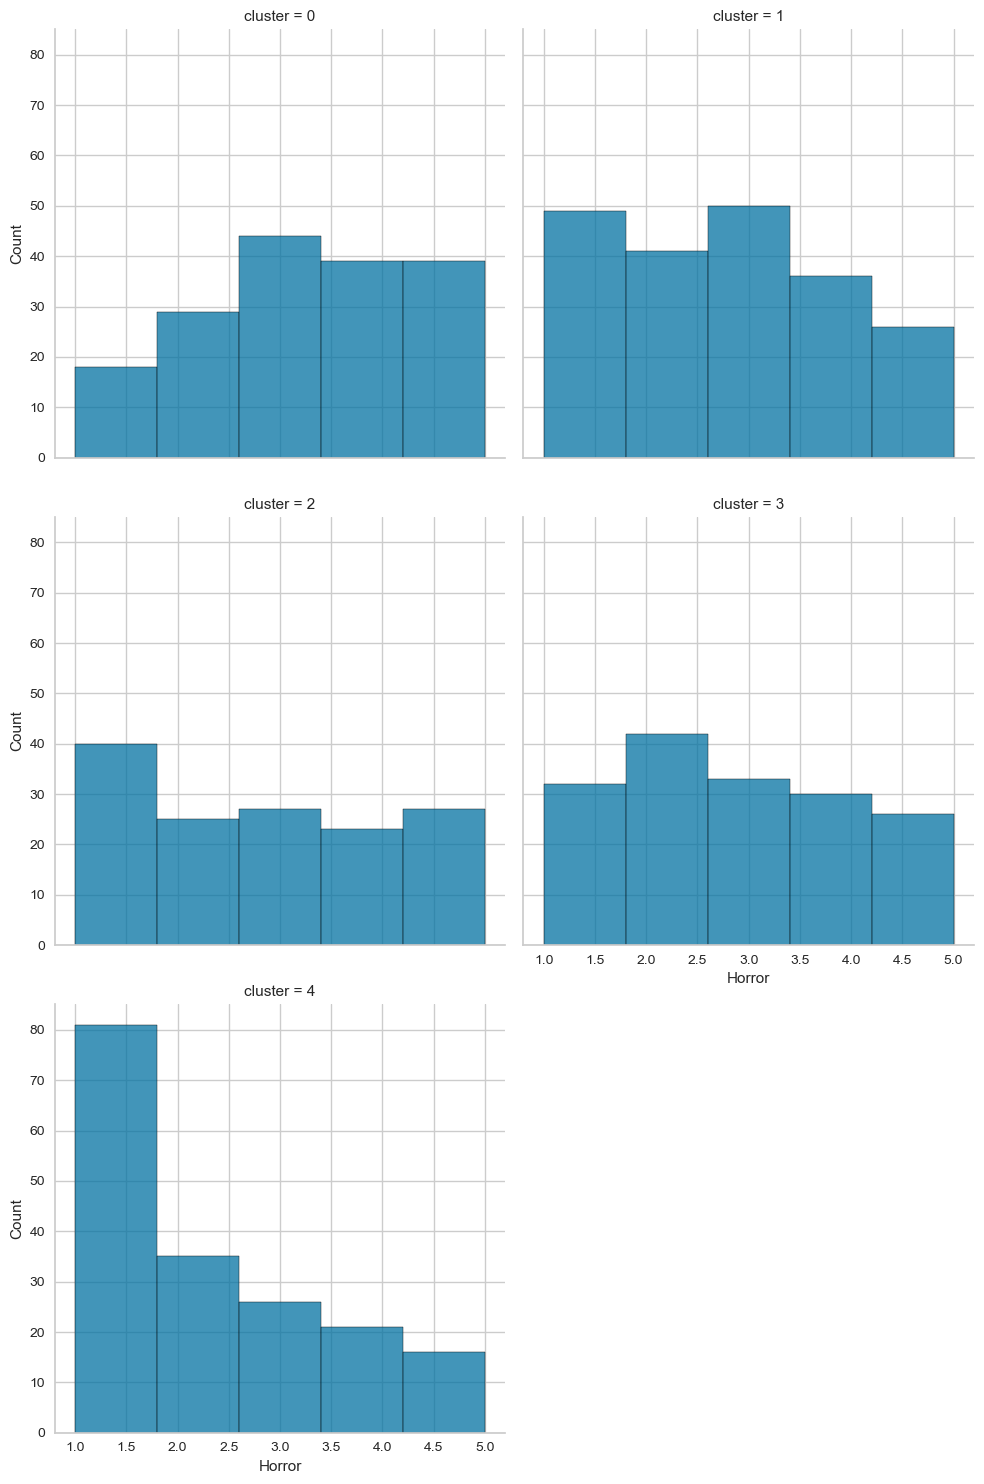

In [28]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Horror", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [27]:
dfrom = df[['Horror', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Horror                                             
         count      mean       std  min  25%  50%  75%  max
cluster                                                    
0        169.0  3.307692  1.290994  1.0  2.0  3.0  4.0  5.0
1        202.0  2.747525  1.345942  1.0  2.0  3.0  4.0  5.0
2        142.0  2.802817  1.483906  1.0  1.0  3.0  4.0  5.0
3        163.0  2.852761  1.361885  1.0  2.0  3.0  4.0  5.0
4        179.0  2.195531  1.357783  1.0  1.0  2.0  3.0  5.0


### Comedy Movies

<Figure size 800x400 with 0 Axes>

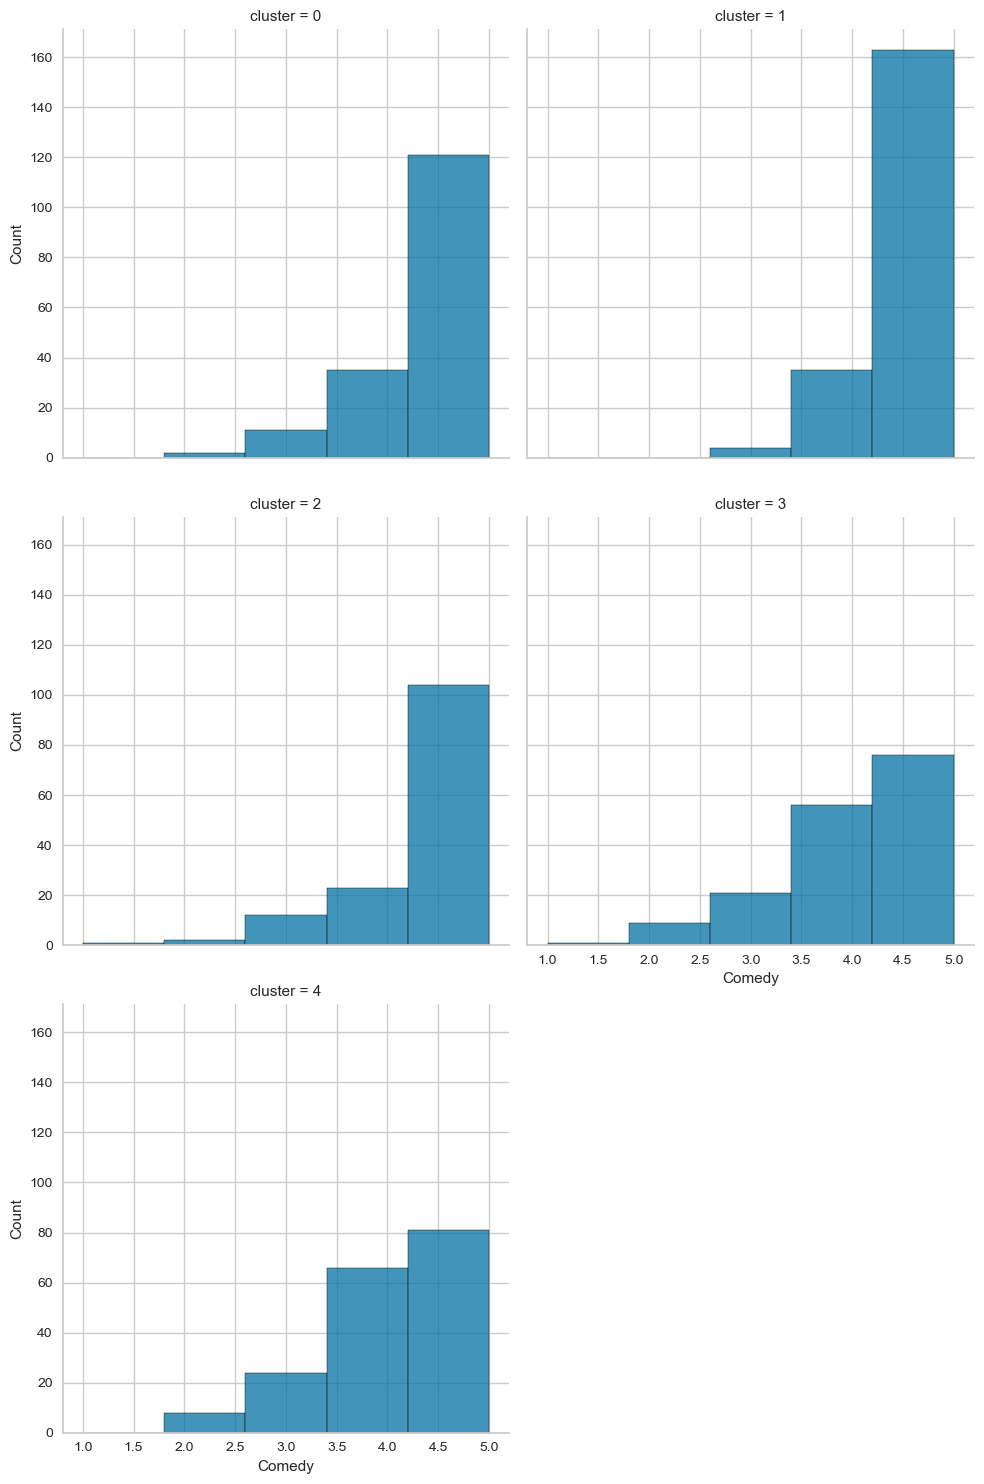

In [29]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Comedy", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [30]:
dfrom = df[['Comedy', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Comedy                                             
         count      mean       std  min  25%  50%  75%  max
cluster                                                    
0        169.0  4.627219  0.661504  2.0  4.0  5.0  5.0  5.0
1        202.0  4.787129  0.456280  3.0  5.0  5.0  5.0  5.0
2        142.0  4.598592  0.763157  1.0  4.0  5.0  5.0  5.0
3        163.0  4.208589  0.912560  1.0  4.0  4.0  5.0  5.0
4        179.0  4.229050  0.846702  2.0  4.0  4.0  5.0  5.0


### Romantic movies

<Figure size 800x400 with 0 Axes>

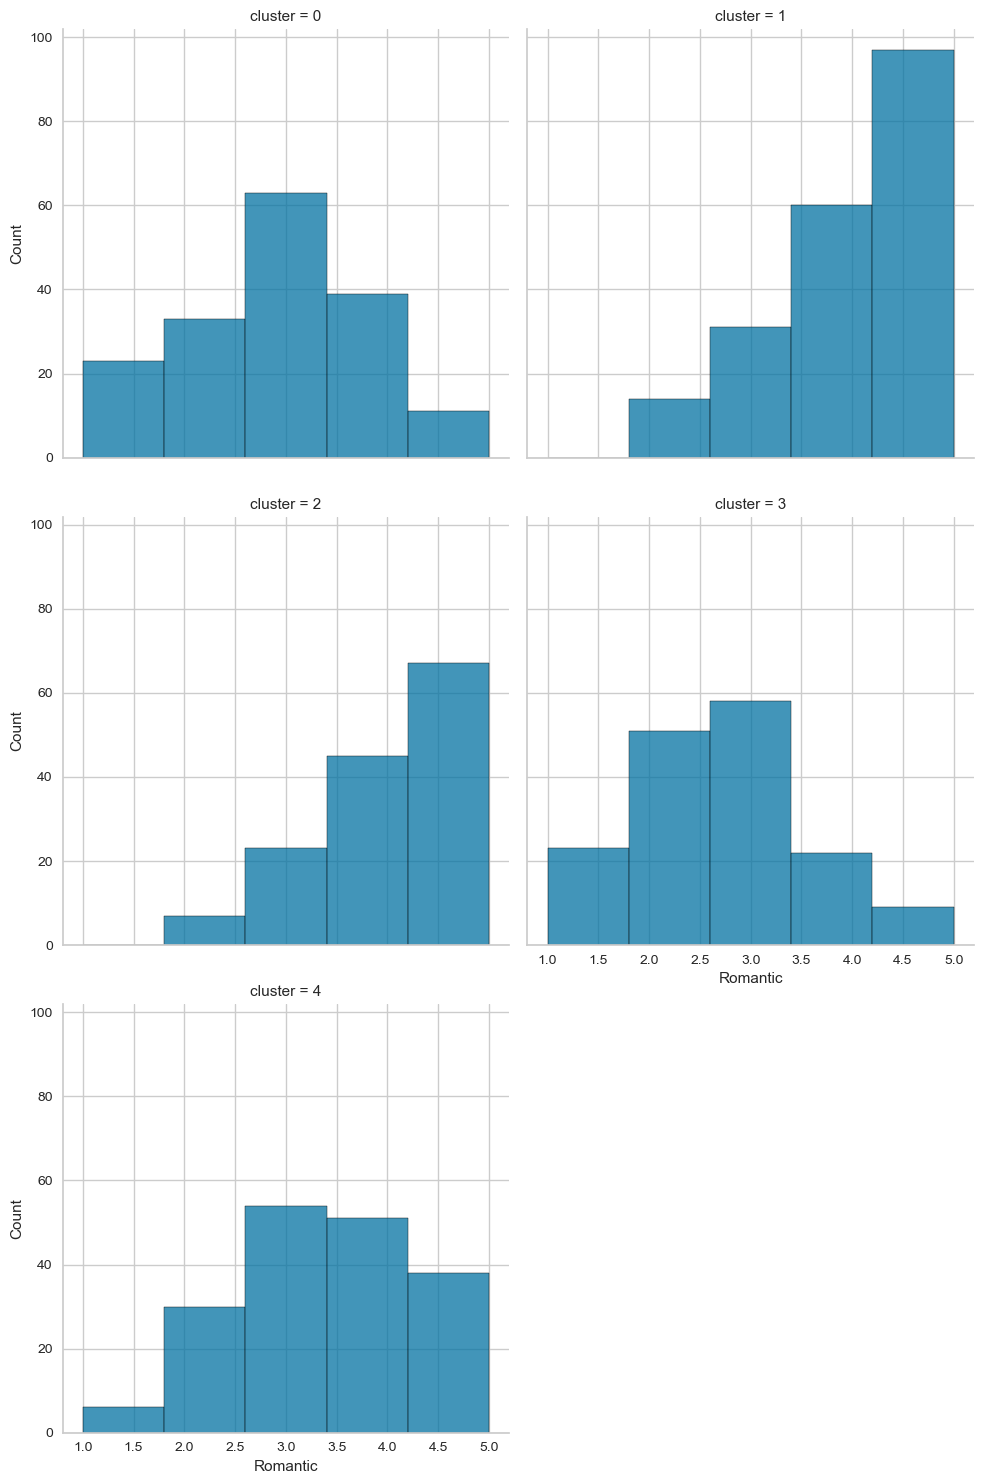

In [31]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Romantic", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [32]:
dfrom = df[['Romantic', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Romantic                                             
           count      mean       std  min  25%  50%  75%  max
cluster                                                      
0          169.0  2.893491  1.107557  1.0  2.0  3.0  4.0  5.0
1          202.0  4.188119  0.938008  2.0  4.0  4.0  5.0  5.0
2          142.0  4.211268  0.889904  2.0  4.0  4.0  5.0  5.0
3          163.0  2.650307  1.057214  1.0  2.0  3.0  3.0  5.0
4          179.0  3.474860  1.103205  1.0  3.0  3.0  4.0  5.0


### Sci Fi Movies

<Figure size 800x400 with 0 Axes>

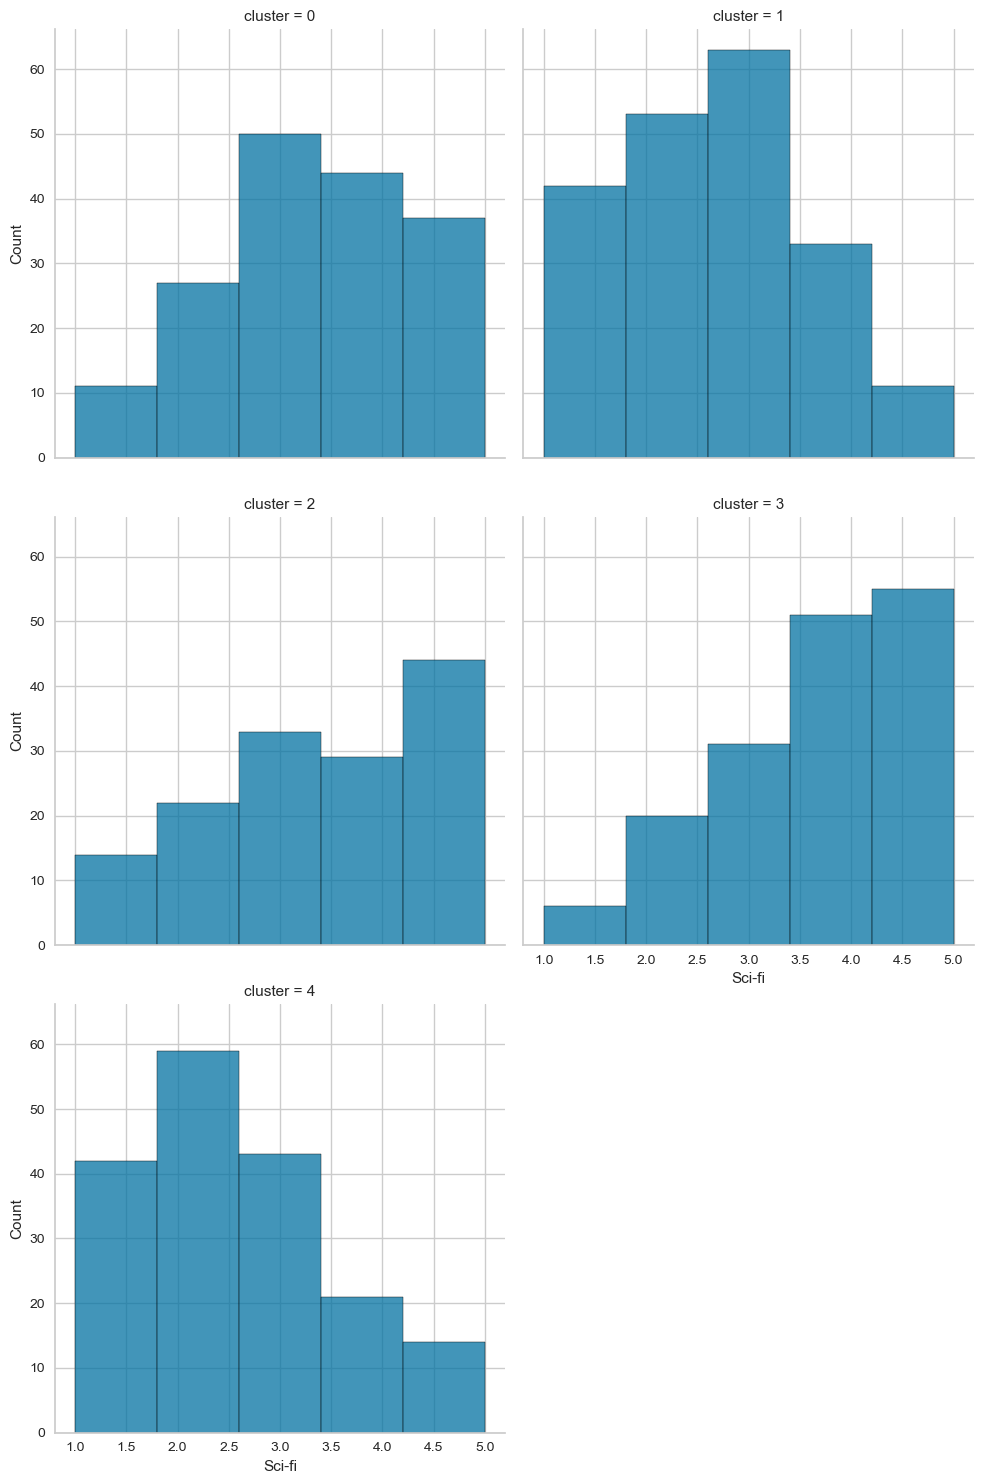

In [33]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Sci-fi", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [34]:
dfrom = df[['Sci-fi', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Sci-fi                                              
         count      mean       std  min   25%  50%  75%  max
cluster                                                     
0        169.0  3.408284  1.182281  1.0  3.00  3.0  4.0  5.0
1        202.0  2.594059  1.147597  1.0  2.00  3.0  3.0  5.0
2        142.0  3.471831  1.335249  1.0  2.25  4.0  5.0  5.0
3        163.0  3.791411  1.146406  1.0  3.00  4.0  5.0  5.0
4        179.0  2.474860  1.196054  1.0  2.00  2.0  3.0  5.0


### War Movies

<Figure size 800x400 with 0 Axes>

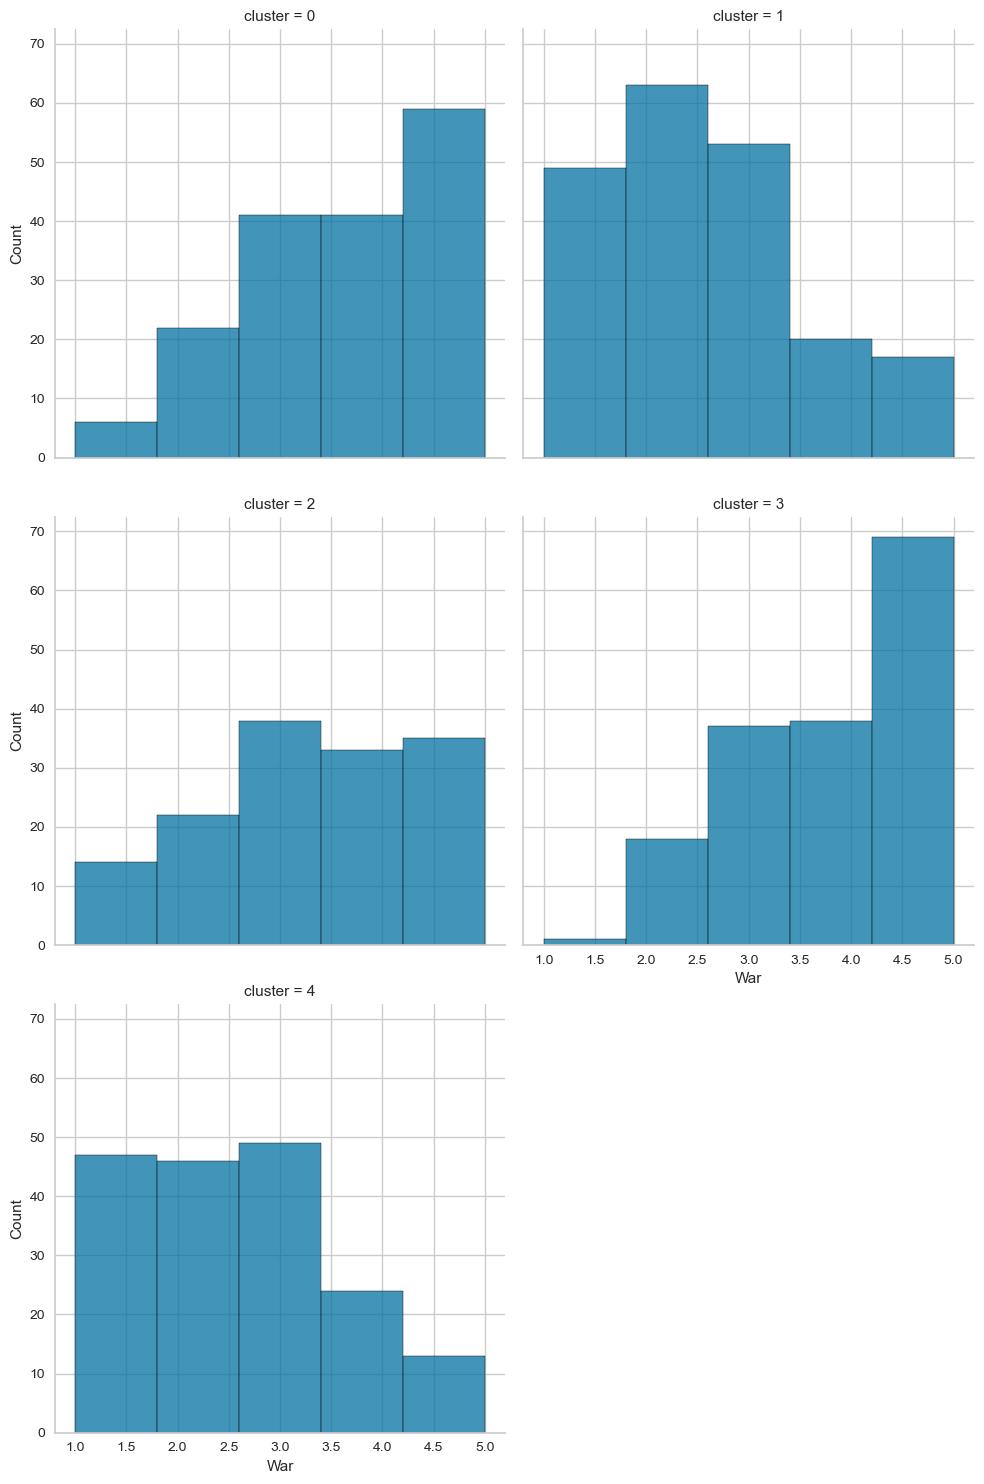

In [35]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="War", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [36]:
dfrom = df[['War', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

           War                                              
         count      mean       std  min   25%  50%  75%  max
cluster                                                     
0        169.0  3.739645  1.171447  1.0  3.00  4.0  5.0  5.0
1        202.0  2.470297  1.201827  1.0  2.00  2.0  3.0  5.0
2        142.0  3.373239  1.280565  1.0  2.25  3.0  4.0  5.0
3        163.0  3.957055  1.073529  1.0  3.00  4.0  5.0  5.0
4        179.0  2.497207  1.219570  1.0  1.00  2.0  3.0  5.0


### Fantasy Movies

<Figure size 800x400 with 0 Axes>

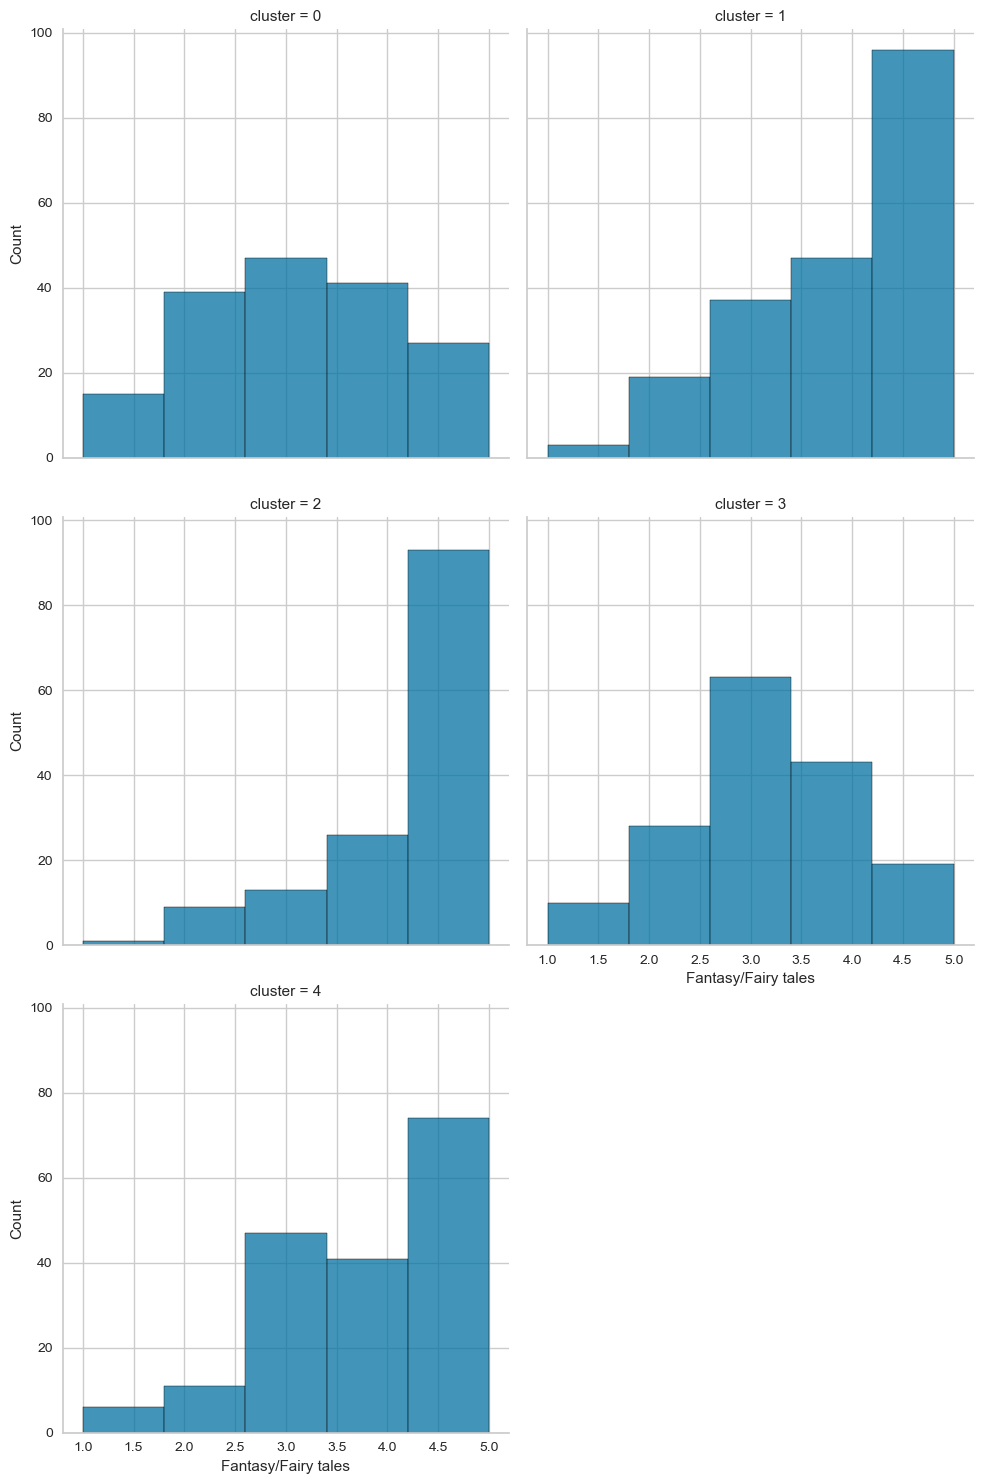

In [37]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Fantasy/Fairy tales", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [38]:
dfrom = df[['Fantasy/Fairy tales', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Fantasy/Fairy tales                                             
                      count      mean       std  min  25%  50%  75%  max
cluster                                                                 
0                     169.0  3.153846  1.205148  1.0  2.0  3.0  4.0  5.0
1                     202.0  4.059406  1.081935  1.0  3.0  4.0  5.0  5.0
2                     142.0  4.415493  0.947134  1.0  4.0  5.0  5.0  5.0
3                     163.0  3.202454  1.055026  1.0  3.0  3.0  4.0  5.0
4                     179.0  3.927374  1.106812  1.0  3.0  4.0  5.0  5.0


### Cartoons Movies

<Figure size 800x400 with 0 Axes>

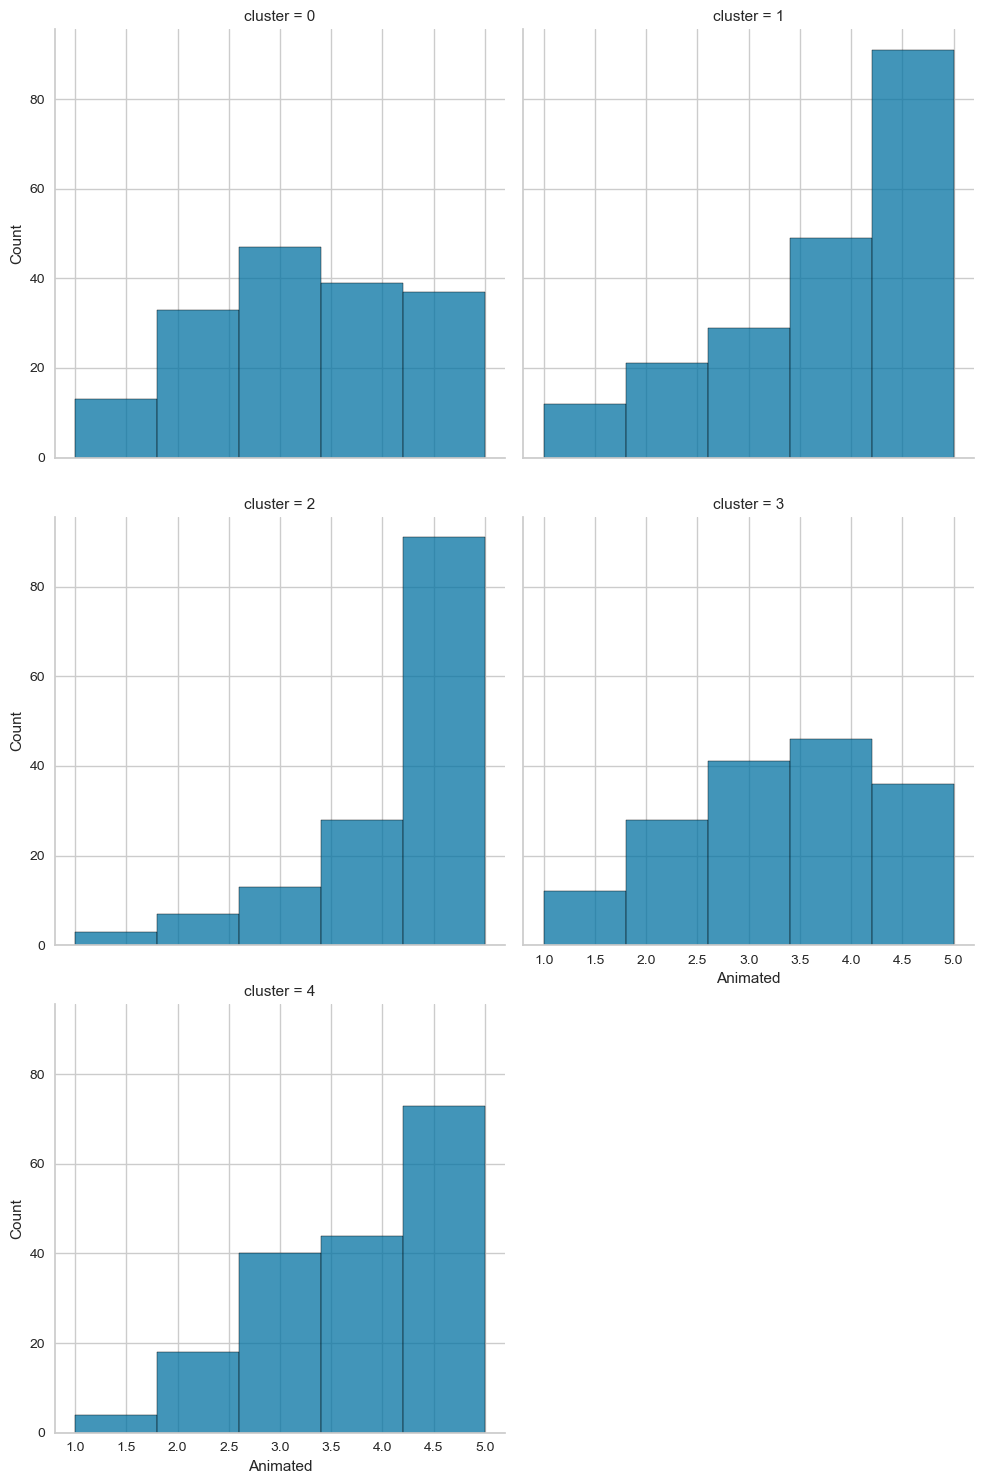

In [39]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Animated", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [40]:
dfrom = df[['Animated', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Animated                                             
           count      mean       std  min  25%  50%  75%  max
cluster                                                      
0          169.0  3.319527  1.231399  1.0  2.0  3.0  4.0  5.0
1          202.0  3.920792  1.243356  1.0  3.0  4.0  5.0  5.0
2          142.0  4.387324  0.988218  1.0  4.0  5.0  5.0  5.0
3          163.0  3.404908  1.215324  1.0  3.0  4.0  4.0  5.0
4          179.0  3.916201  1.111086  1.0  3.0  4.0  5.0  5.0


### Documentary Movies

<Figure size 800x400 with 0 Axes>

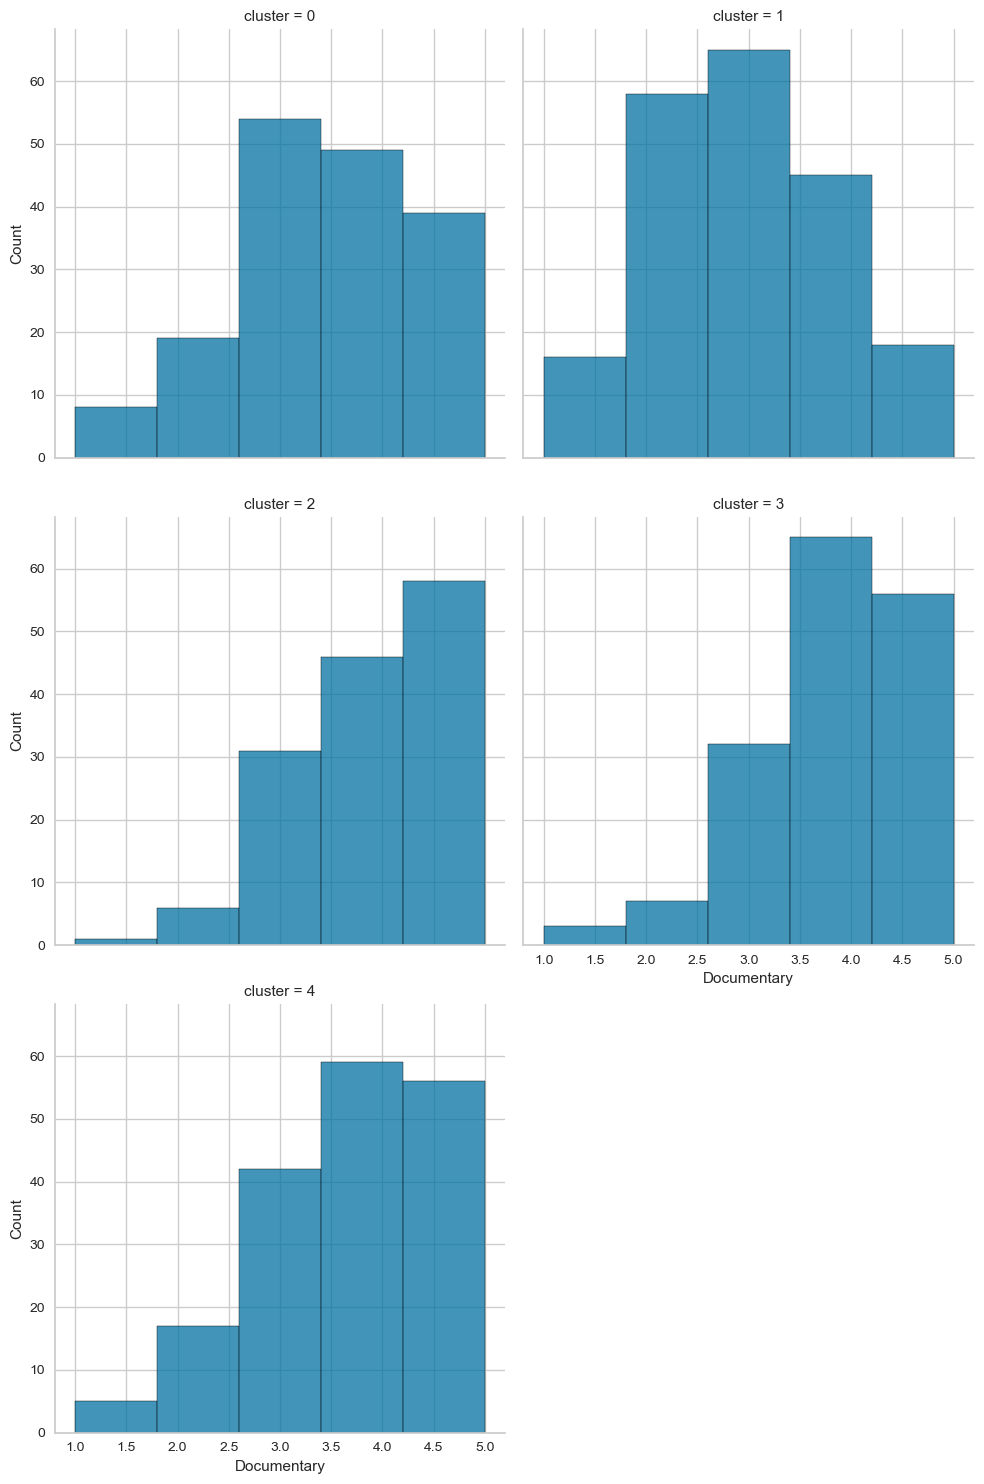

In [42]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Documentary", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [43]:
dfrom = df[['Documentary', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Documentary                                             
              count      mean       std  min  25%  50%  75%  max
cluster                                                         
0             169.0  3.544379  1.107112  1.0  3.0  4.0  4.0  5.0
1             202.0  2.955446  1.089523  1.0  2.0  3.0  4.0  5.0
2             142.0  4.084507  0.926313  1.0  3.0  4.0  5.0  5.0
3             163.0  4.006135  0.939510  1.0  3.0  4.0  5.0  5.0
4             179.0  3.804469  1.070956  1.0  3.0  4.0  5.0  5.0


### Western Movies

<Figure size 800x400 with 0 Axes>

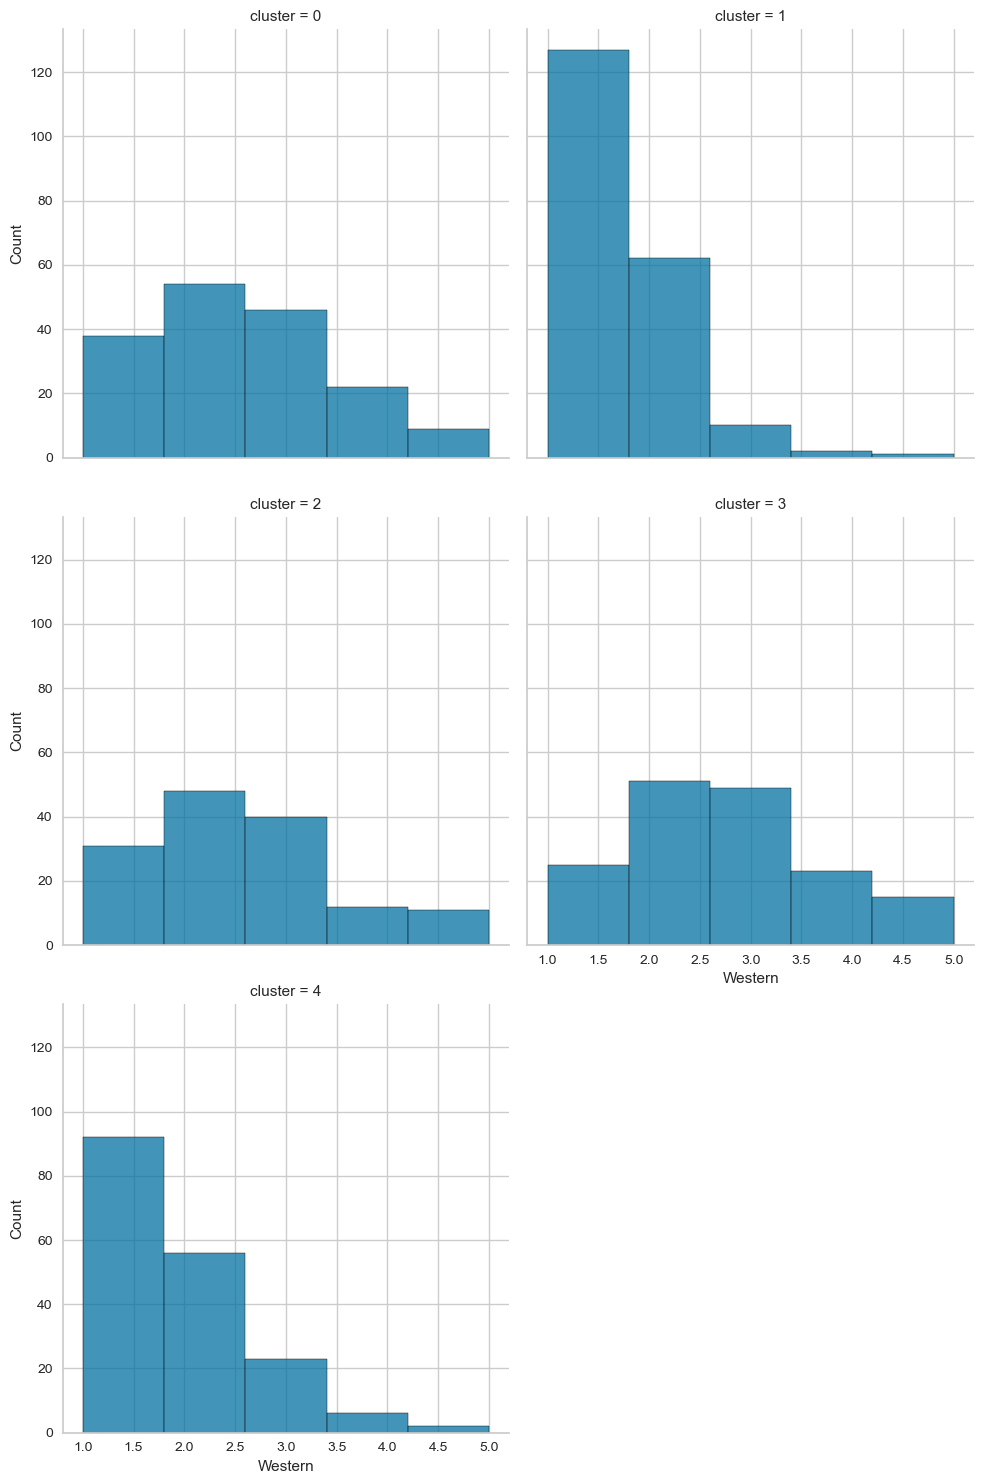

In [44]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Western", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [45]:
dfrom = df[['Western', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Western                                             
          count      mean       std  min  25%  50%  75%  max
cluster                                                     
0         169.0  2.467456  1.134080  1.0  2.0  2.0  3.0  5.0
1         202.0  1.455446  0.684218  1.0  1.0  1.0  2.0  5.0
2         142.0  2.464789  1.152622  1.0  2.0  2.0  3.0  5.0
3         163.0  2.705521  1.164986  1.0  2.0  3.0  3.0  5.0
4         179.0  1.715084  0.894645  1.0  1.0  1.0  2.0  5.0


### Action Movies

<Figure size 800x400 with 0 Axes>

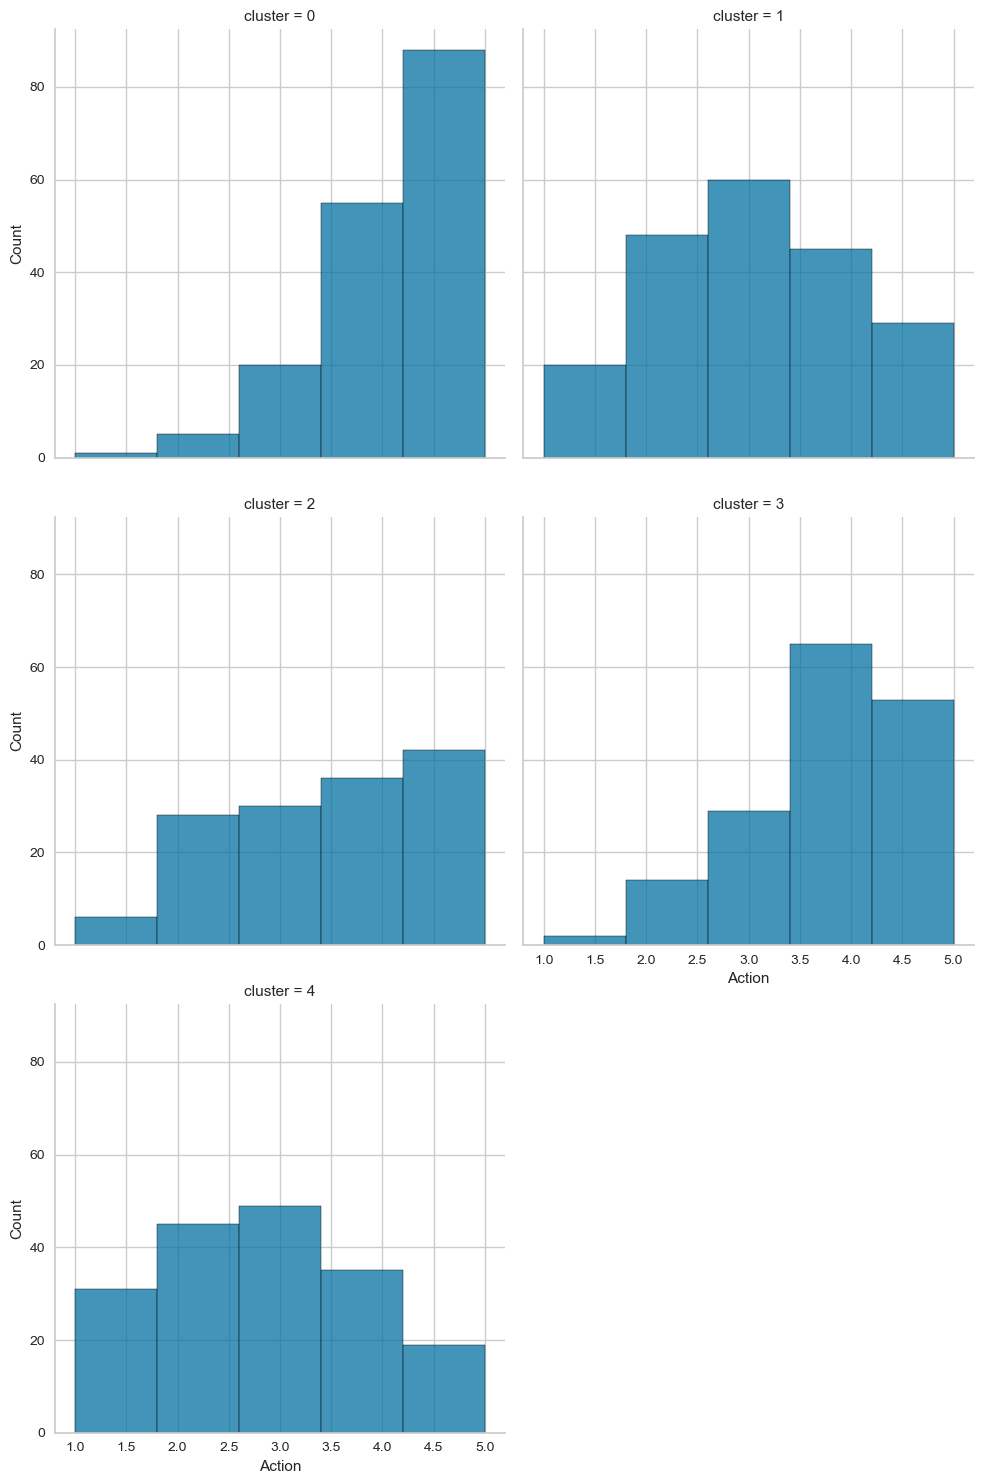

In [46]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Action", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [47]:
dfrom = df[['Action', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Action                                             
         count      mean       std  min  25%  50%  75%  max
cluster                                                    
0        169.0  4.325444  0.841981  1.0  4.0  5.0  5.0  5.0
1        202.0  3.074257  1.196775  1.0  2.0  3.0  4.0  5.0
2        142.0  3.563380  1.223092  1.0  3.0  4.0  5.0  5.0
3        163.0  3.938650  0.979375  1.0  3.0  4.0  5.0  5.0
4        179.0  2.810056  1.239658  1.0  2.0  3.0  4.0  5.0


## Survey Responses: Hobbies and Interests

### Cars

Interest in Cars


<Figure size 800x400 with 0 Axes>

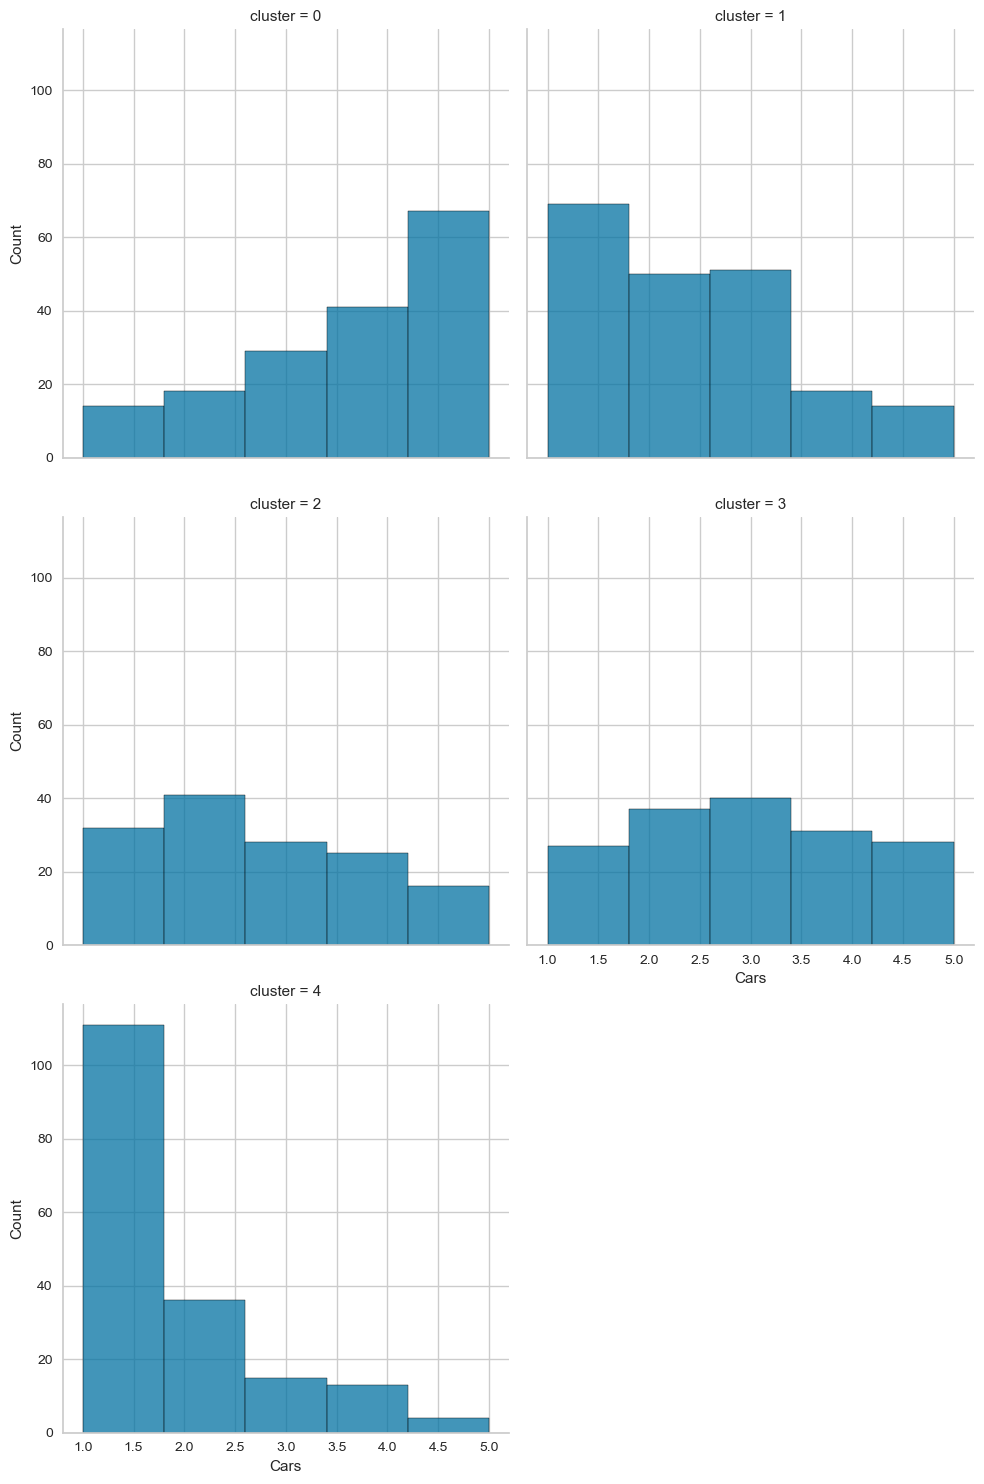

In [49]:
plt.figure(figsize=(8,4))
print("Interest in Cars")
sns.displot(data=df, x="Cars", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [50]:
dfrom = df[['Cars', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

          Cars                                             
         count      mean       std  min  25%  50%  75%  max
cluster                                                    
0        169.0  3.763314  1.301402  1.0  3.0  4.0  5.0  5.0
1        202.0  2.297030  1.222057  1.0  1.0  2.0  3.0  5.0
2        142.0  2.661972  1.309471  1.0  2.0  2.0  4.0  5.0
3        163.0  2.975460  1.333106  1.0  2.0  3.0  4.0  5.0
4        179.0  1.675978  1.047219  1.0  1.0  1.0  2.0  5.0


### Art

<Figure size 800x400 with 0 Axes>

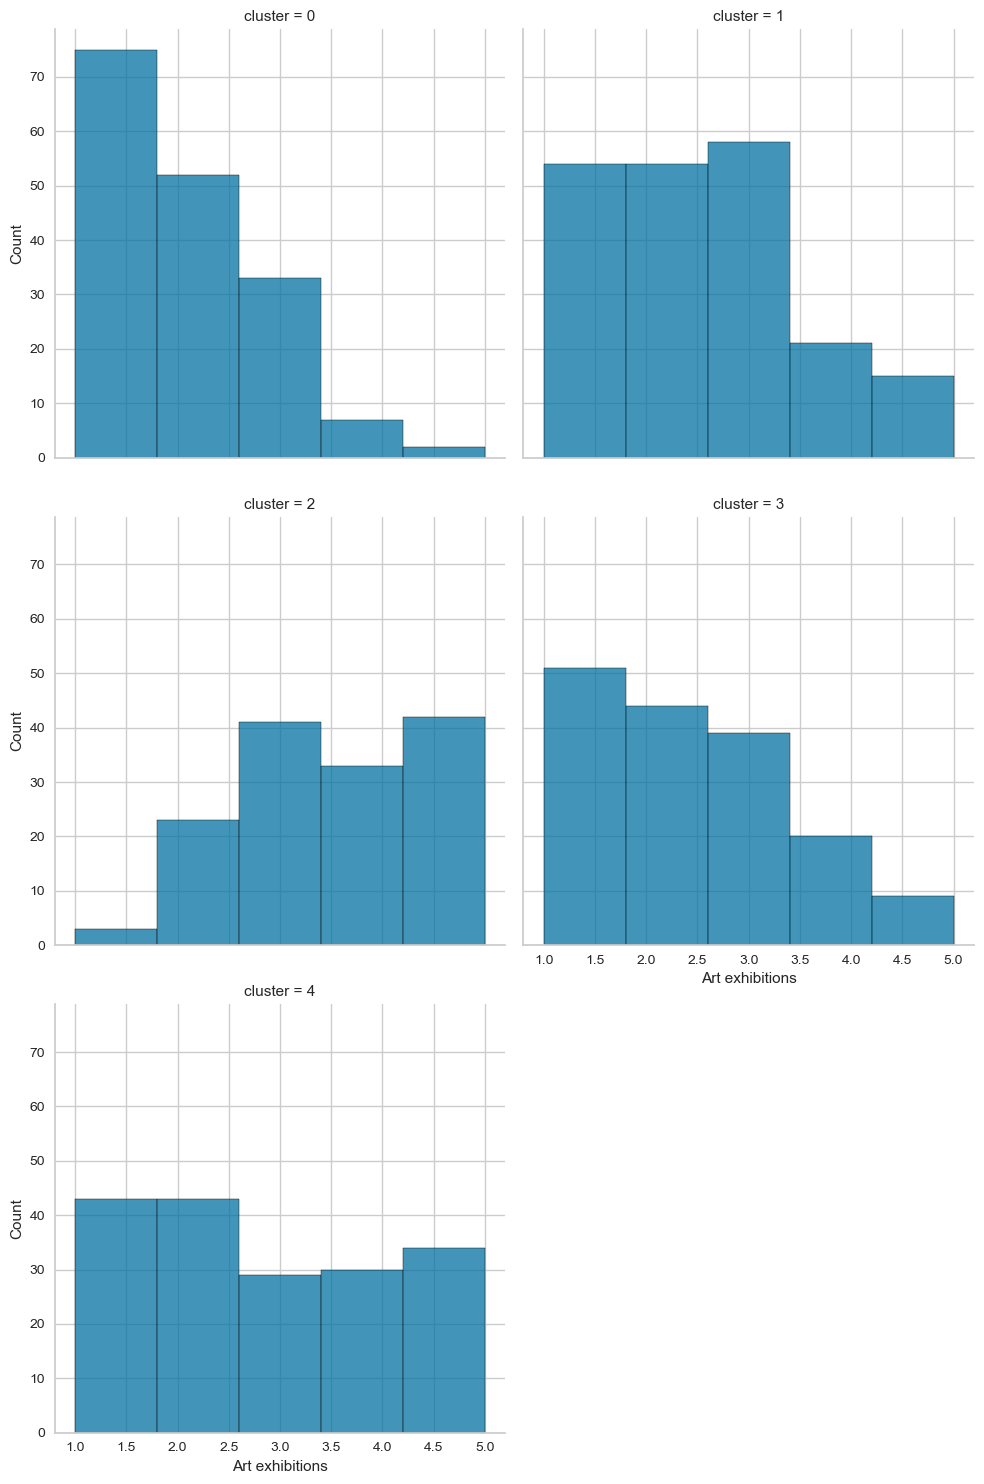

In [51]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Art exhibitions", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [52]:
dfrom = df[['Art exhibitions', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Art exhibitions                                             
                  count      mean       std  min  25%  50%  75%  max
cluster                                                             
0                 169.0  1.869822  0.948483  1.0  1.0  2.0  2.0  5.0
1                 202.0  2.450495  1.201171  1.0  1.0  2.0  3.0  5.0
2                 142.0  3.619718  1.134453  1.0  3.0  4.0  5.0  5.0
3                 163.0  2.337423  1.197842  1.0  1.0  2.0  3.0  5.0
4                 179.0  2.826816  1.452683  1.0  2.0  3.0  4.0  5.0


### Adrenaline sport

<Figure size 800x400 with 0 Axes>

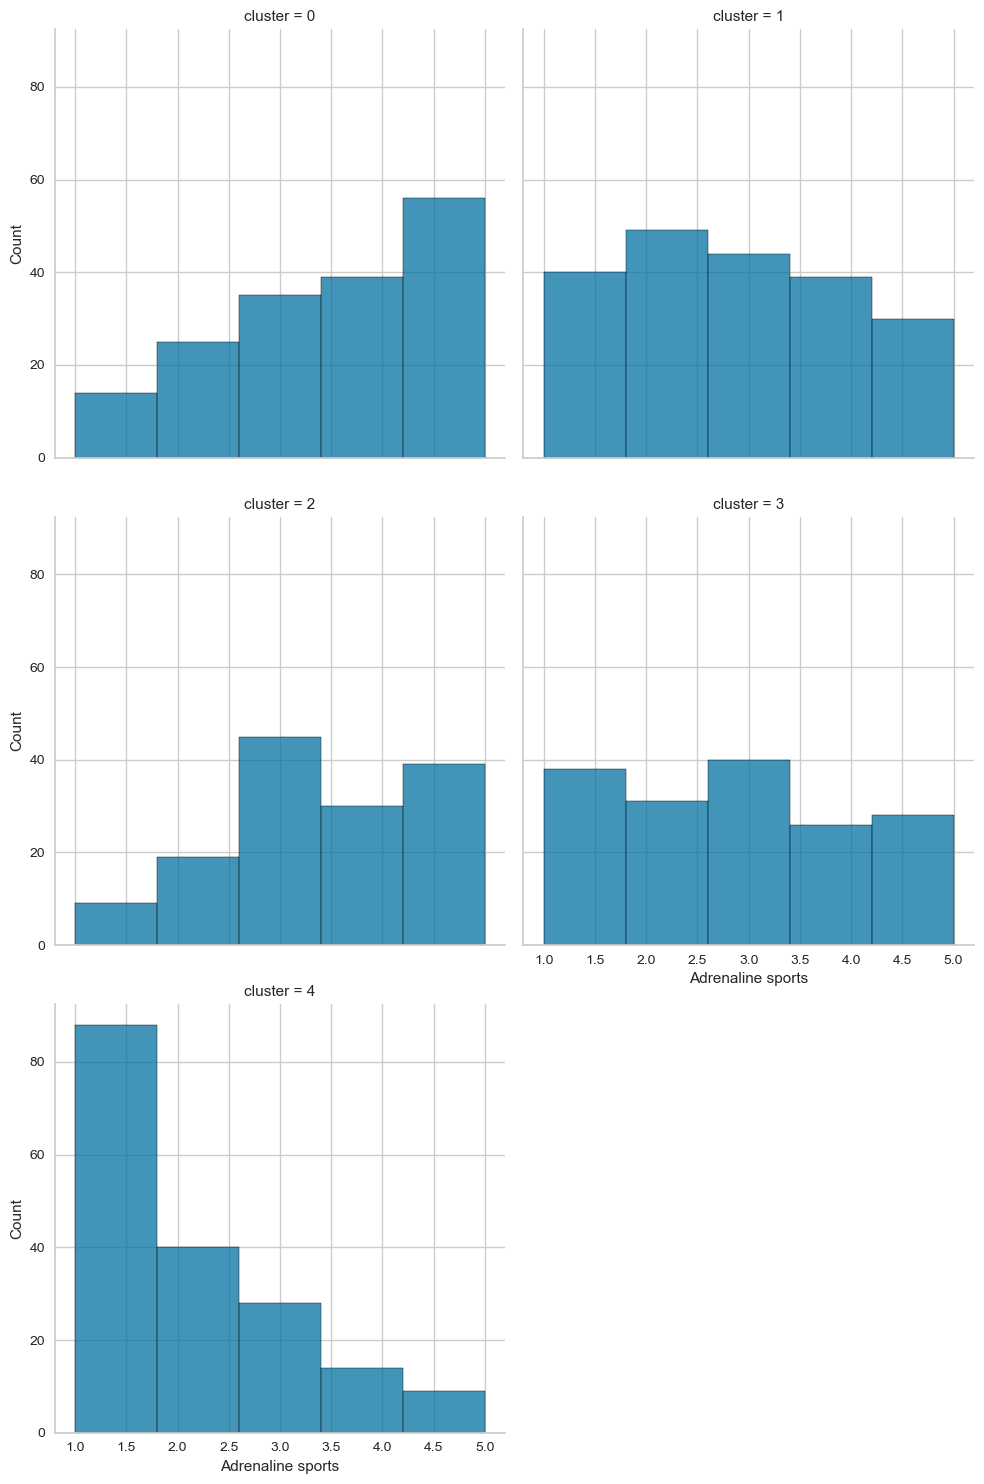

In [53]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Adrenaline sports", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [54]:
dfrom = df[['Adrenaline sports', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Adrenaline sports                                             
                    count      mean       std  min  25%  50%  75%  max
cluster                                                               
0                   169.0  3.579882  1.307423  1.0  3.0  4.0  5.0  5.0
1                   202.0  2.851485  1.344872  1.0  2.0  3.0  4.0  5.0
2                   142.0  3.500000  1.207248  1.0  3.0  3.0  5.0  5.0
3                   163.0  2.846626  1.399219  1.0  2.0  3.0  4.0  5.0
4                   179.0  1.972067  1.191874  1.0  1.0  2.0  3.0  5.0


### Celebrities

<Figure size 800x400 with 0 Axes>

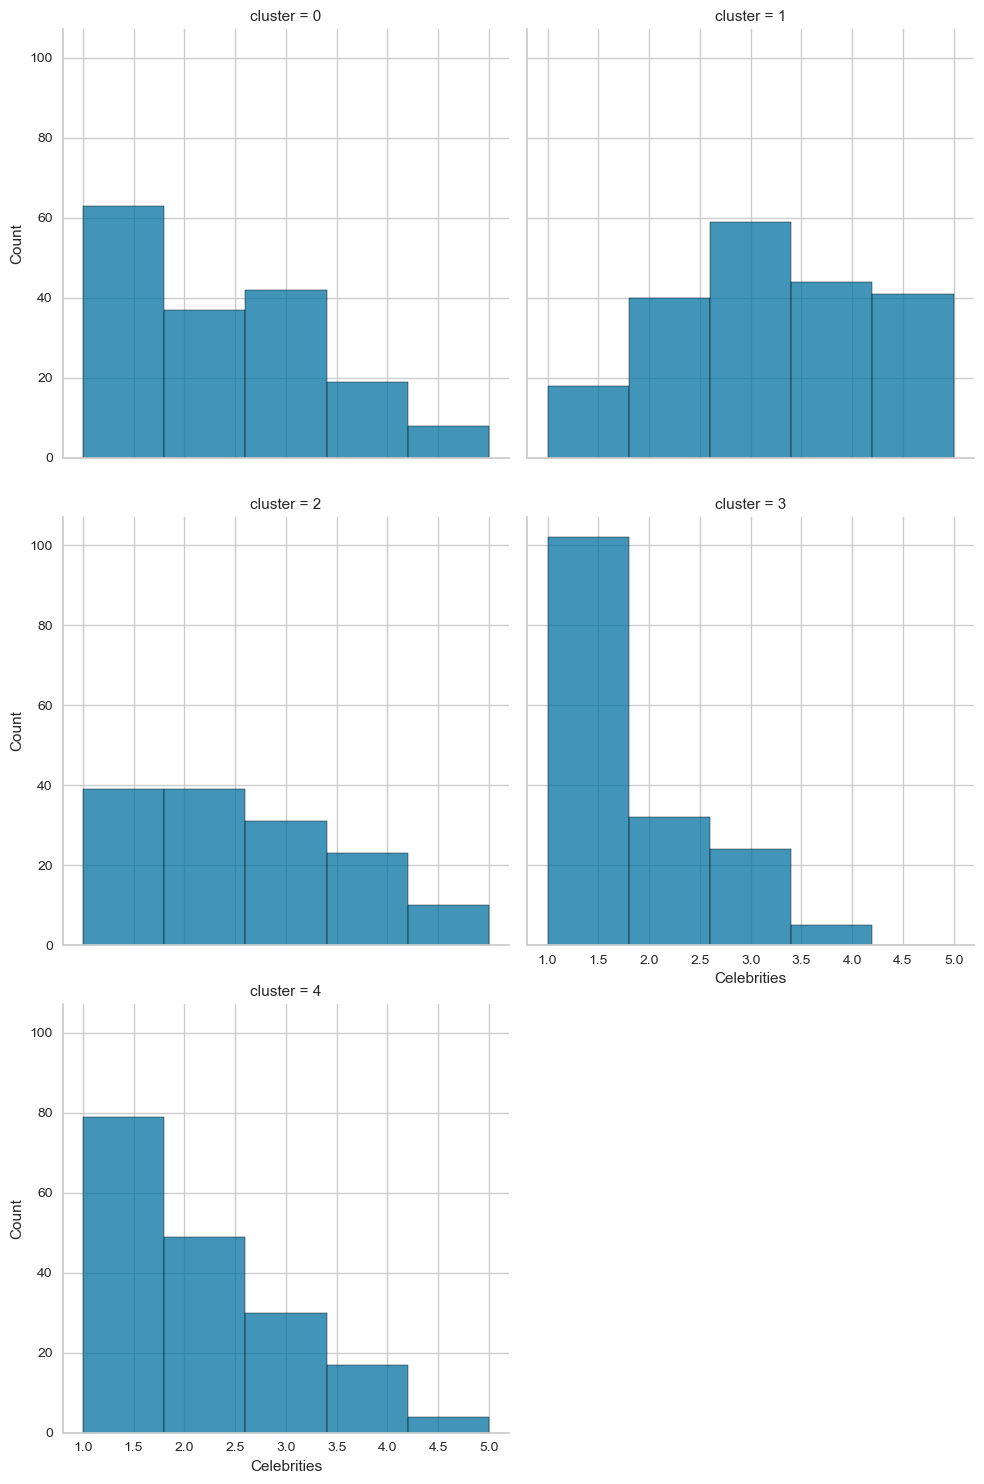

In [55]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Celebrities", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [56]:
dfrom = df[['Celebrities', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Celebrities                                             
              count      mean       std  min  25%  50%  75%  max
cluster                                                         
0             169.0  2.242604  1.202807  1.0  1.0  2.0  3.0  5.0
1             202.0  3.247525  1.237120  1.0  2.0  3.0  4.0  5.0
2             142.0  2.478873  1.247513  1.0  1.0  2.0  3.0  5.0
3             163.0  1.582822  0.852128  1.0  1.0  1.0  2.0  4.0
4             179.0  1.983240  1.093776  1.0  1.0  2.0  3.0  5.0


### Shopping

<Figure size 800x400 with 0 Axes>

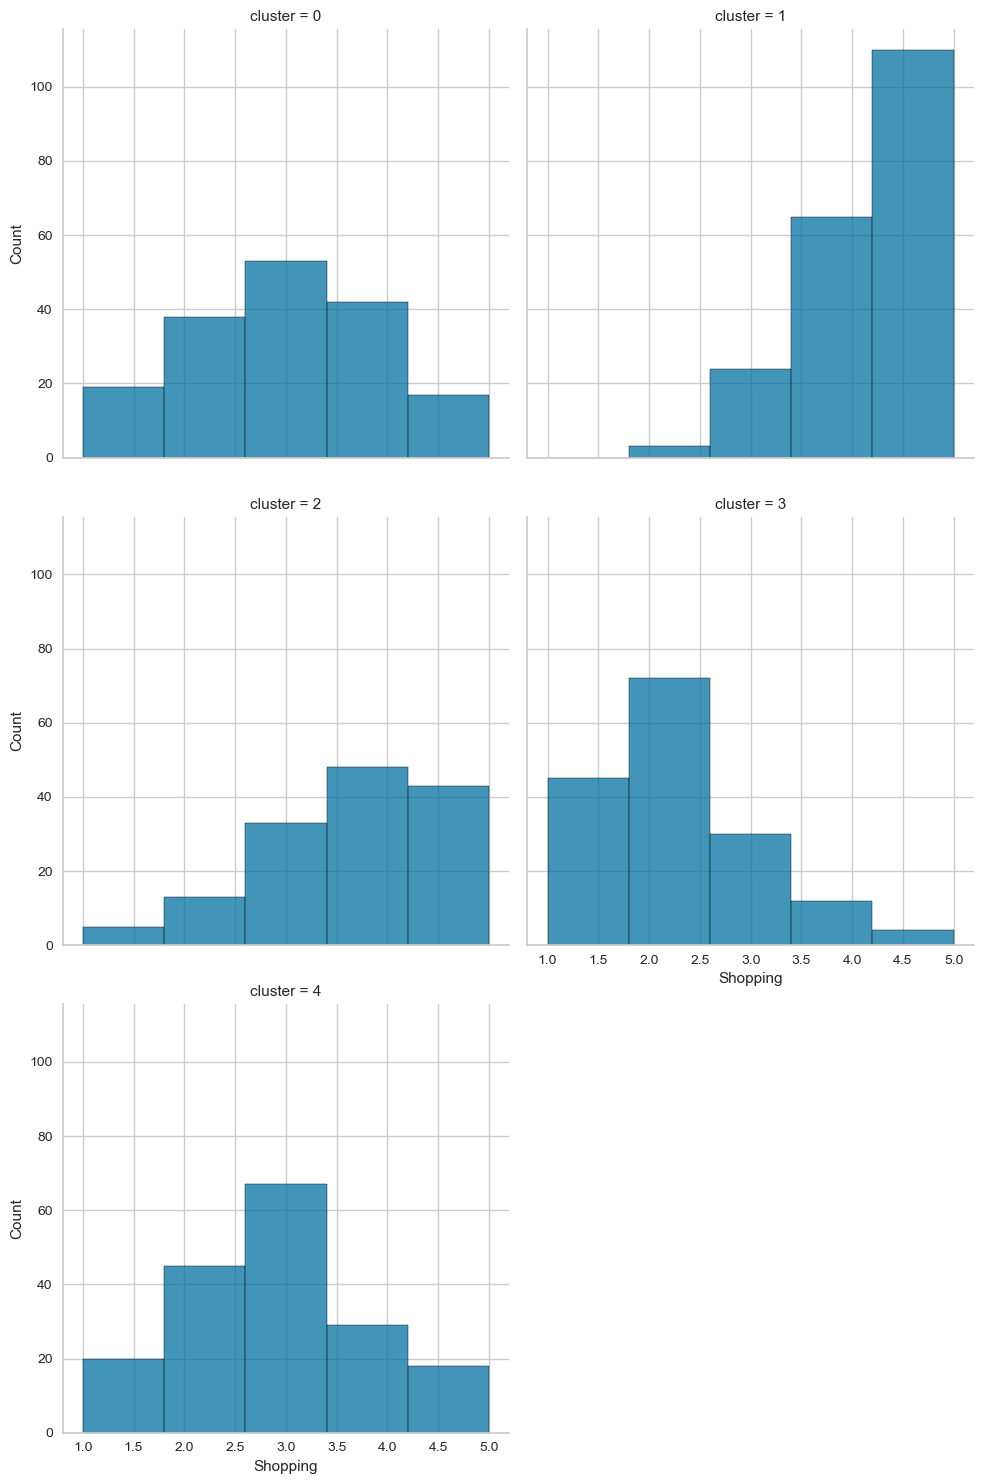

In [57]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Shopping", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [58]:
dfrom = df[['Shopping', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Shopping                                             
           count      mean       std  min  25%  50%  75%  max
cluster                                                      
0          169.0  3.000000  1.154701  1.0  2.0  3.0  4.0  5.0
1          202.0  4.396040  0.754149  2.0  4.0  5.0  5.0  5.0
2          142.0  3.781690  1.085796  1.0  3.0  4.0  5.0  5.0
3          163.0  2.128834  0.982233  1.0  1.0  2.0  3.0  5.0
4          179.0  2.888268  1.121209  1.0  2.0  3.0  4.0  5.0


### Theatre

<Figure size 800x400 with 0 Axes>

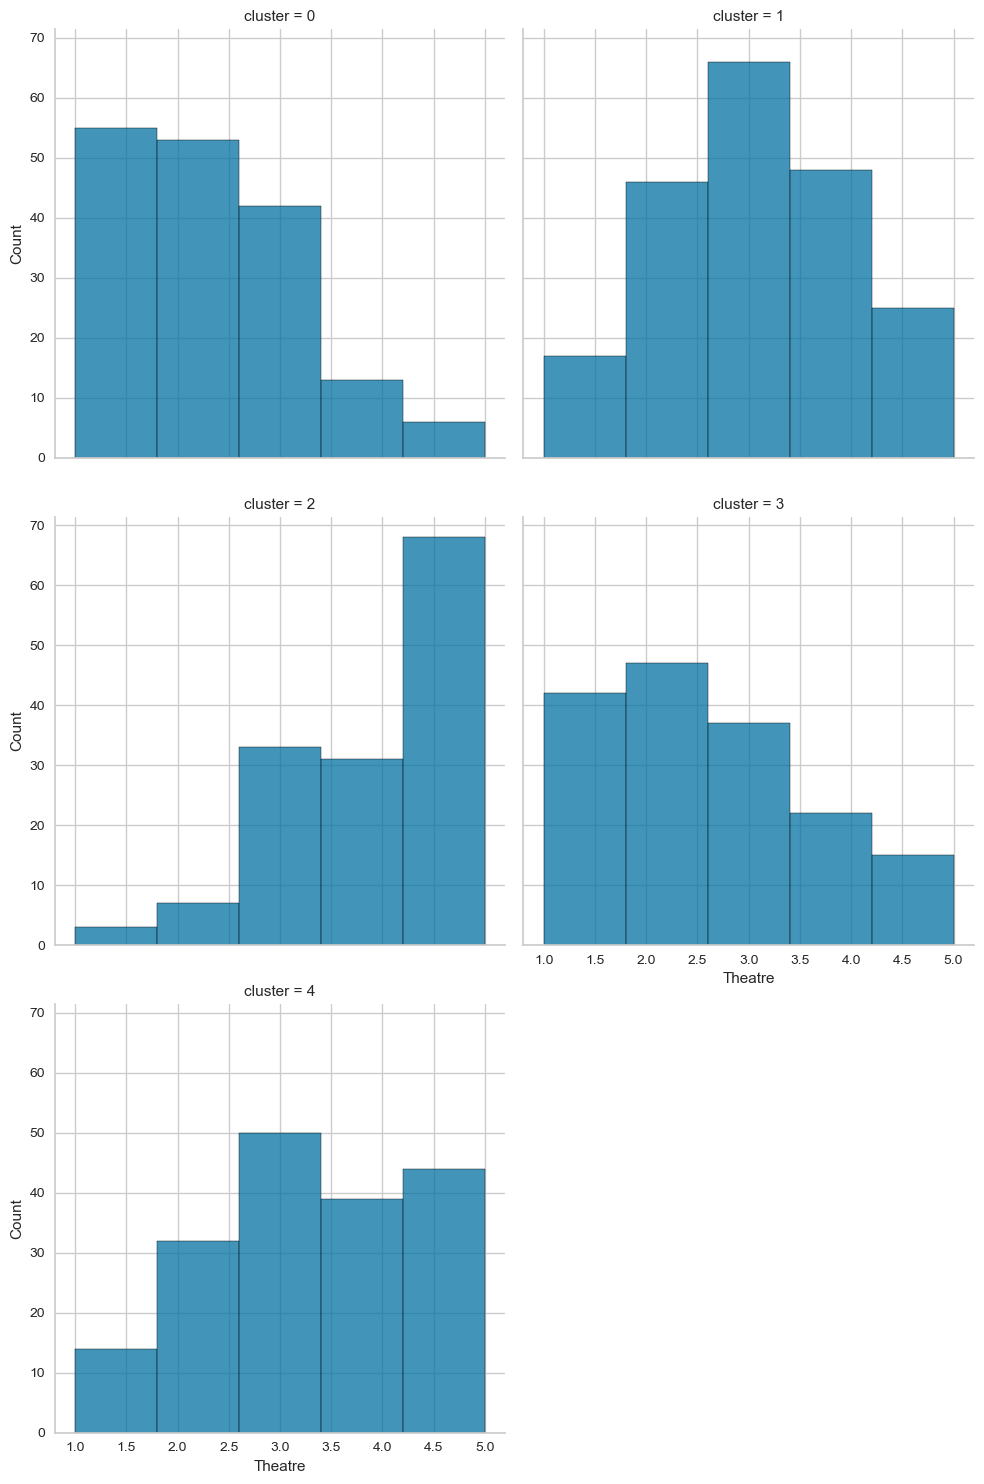

In [61]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Theatre", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [62]:
dfrom = df[['Theatre', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Theatre                                             
          count      mean       std  min  25%  50%  75%  max
cluster                                                     
0         169.0  2.183432  1.083737  1.0  1.0  2.0  3.0  5.0
1         202.0  3.089109  1.138202  1.0  2.0  3.0  4.0  5.0
2         142.0  4.084507  1.048423  1.0  3.0  4.0  5.0  5.0
3         163.0  2.515337  1.263719  1.0  1.0  2.0  3.0  5.0
4         179.0  3.374302  1.249543  1.0  2.0  3.0  4.0  5.0


### Socializing

<Figure size 800x400 with 0 Axes>

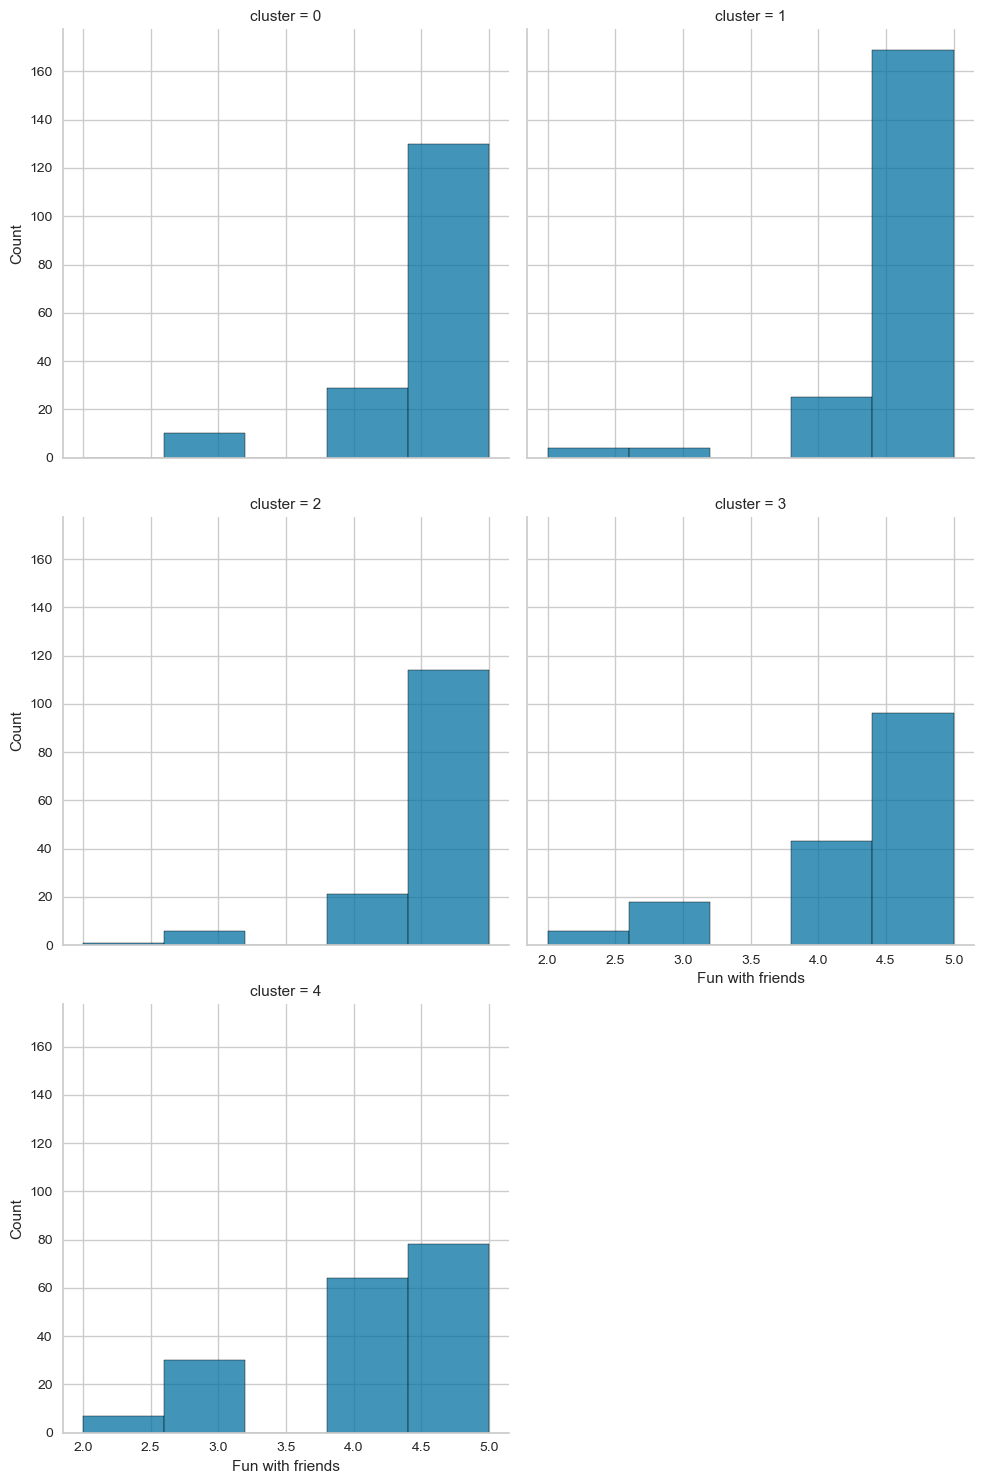

In [63]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Fun with friends", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [64]:
dfrom = df[['Fun with friends', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Fun with friends                                             
                   count      mean       std  min  25%  50%  75%  max
cluster                                                              
0                  169.0  4.710059  0.571094  3.0  5.0  5.0  5.0  5.0
1                  202.0  4.777228  0.577244  2.0  5.0  5.0  5.0  5.0
2                  142.0  4.746479  0.564136  2.0  5.0  5.0  5.0  5.0
3                  163.0  4.404908  0.828788  2.0  4.0  5.0  5.0  5.0
4                  179.0  4.189944  0.853091  2.0  4.0  4.0  5.0  5.0


## Survey Responses: Lifestyle Preferences

### "I enjoy meeting new people"

<Figure size 800x400 with 0 Axes>

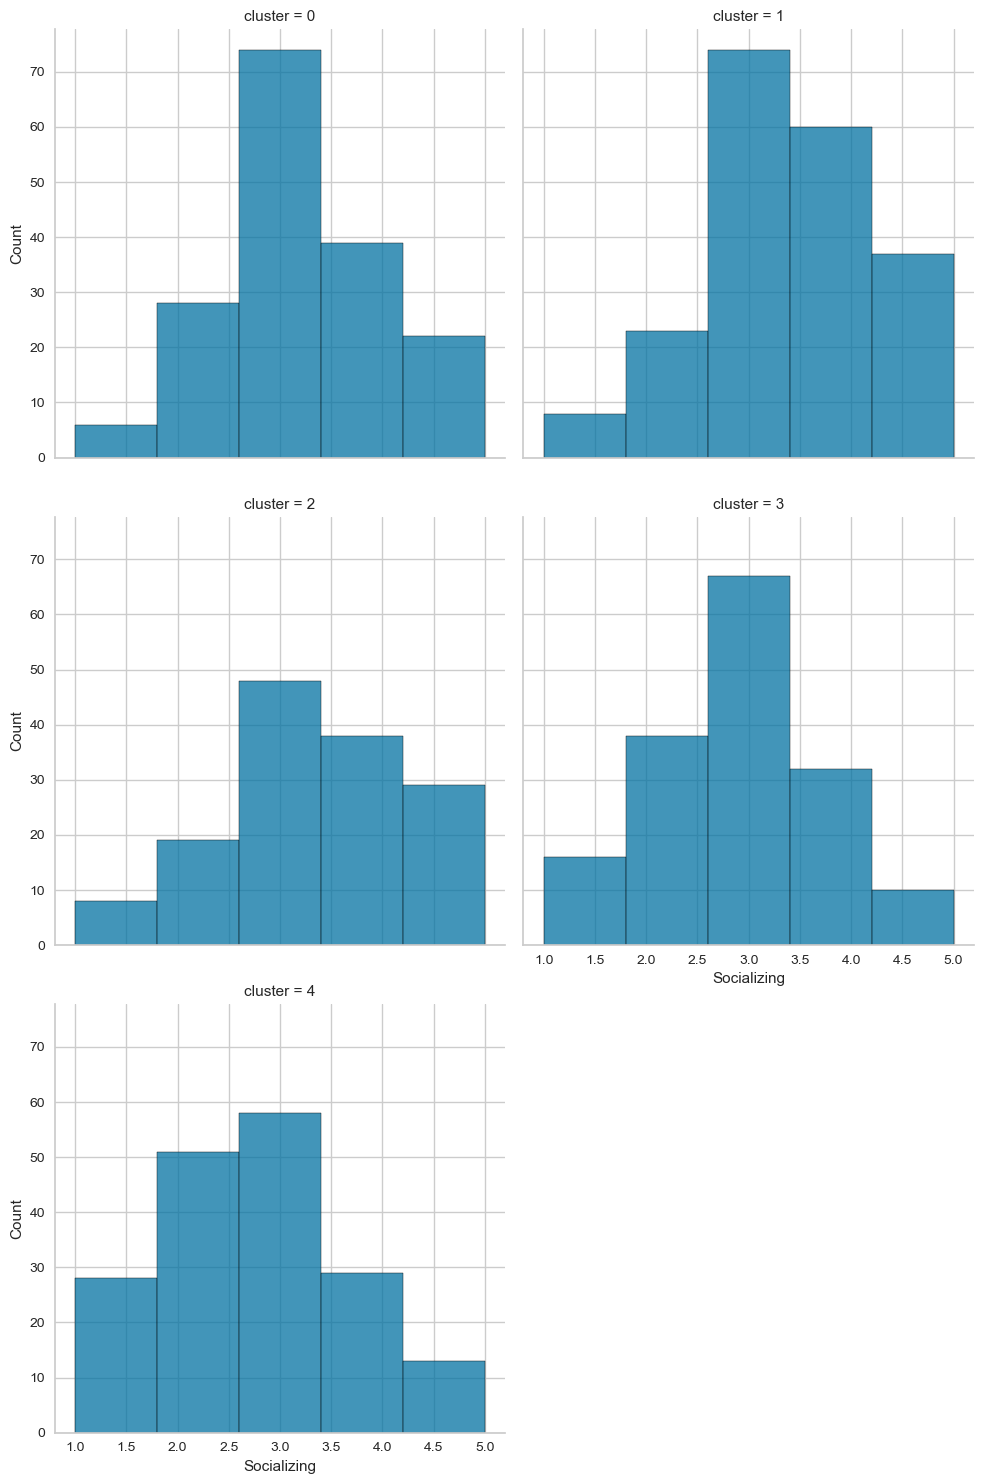

In [65]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Socializing", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [66]:
dfrom = df[['Socializing', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Socializing                                             
              count      mean       std  min  25%  50%  75%  max
cluster                                                         
0             169.0  3.254438  1.000176  1.0  3.0  3.0  4.0  5.0
1             202.0  3.470297  1.042199  1.0  3.0  3.0  4.0  5.0
2             142.0  3.429577  1.126080  1.0  3.0  3.0  4.0  5.0
3             163.0  2.889571  1.030439  1.0  2.0  3.0  4.0  5.0
4             179.0  2.709497  1.133984  1.0  2.0  3.0  3.0  5.0


### "I prefer fast music"

<Figure size 800x400 with 0 Axes>

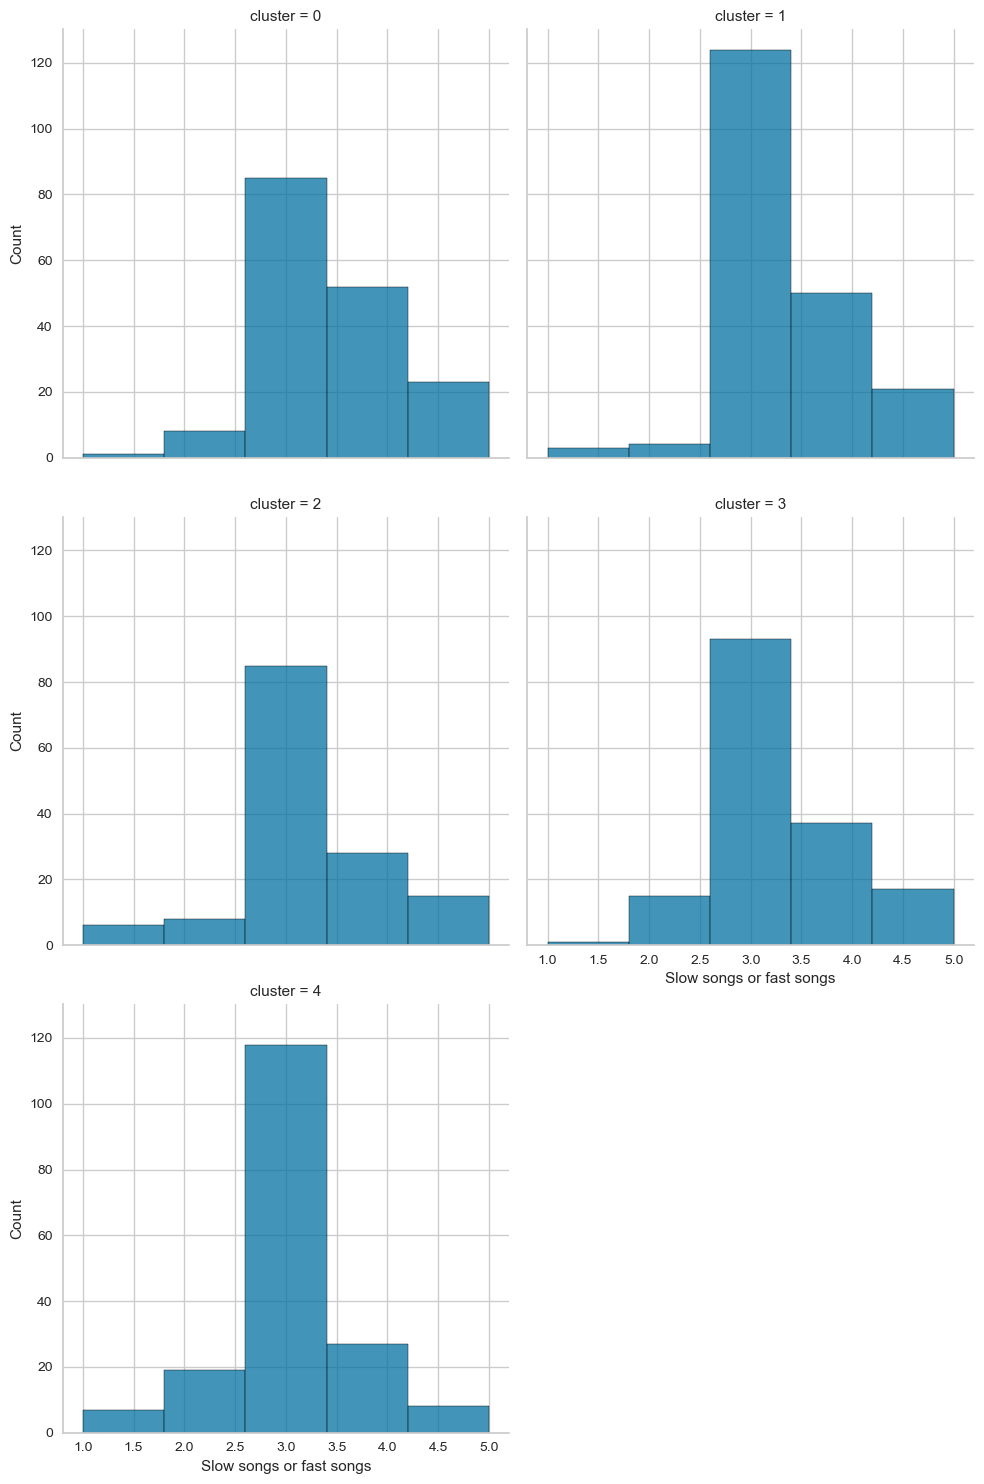

In [67]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Slow songs or fast songs", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [ ]:
dfrom = df[['Slow songs or fast songs', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

### "I will happily pay more money for good, quality or healthy food"

<Figure size 800x400 with 0 Axes>

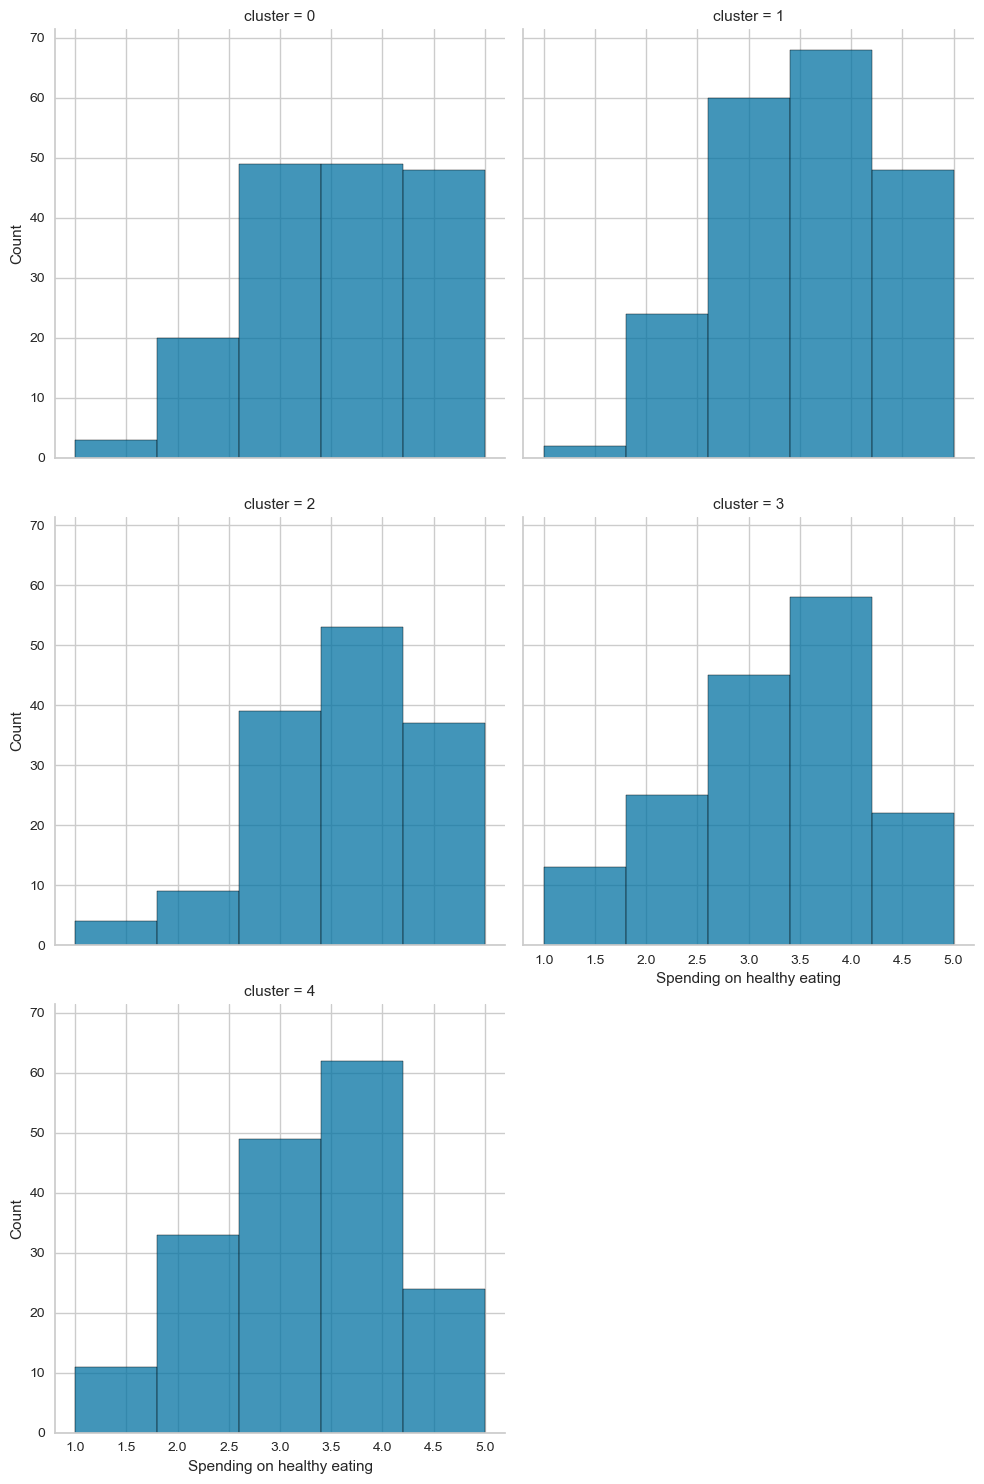

In [68]:
plt.figure(figsize=(8,4))
sns.displot(data=df, x="Spending on healthy eating", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [70]:
dfrom = df[['Spending on healthy eating', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Spending on healthy eating                                          \
                             count      mean       std  min  25%  50%  75%   
cluster                                                                      
0                            169.0  3.704142  1.061241  1.0  3.0  4.0  5.0   
1                            202.0  3.673267  0.998595  1.0  3.0  4.0  4.0   
2                            142.0  3.774648  0.999251  1.0  3.0  4.0  5.0   
3                            163.0  3.312883  1.130506  1.0  3.0  3.0  4.0   
4                            179.0  3.307263  1.106925  1.0  3.0  3.0  4.0   

              
         max  
cluster       
0        5.0  
1        5.0  
2        5.0  
3        5.0  
4        5.0  


## Demographics

### Male

Male


<Figure size 800x400 with 0 Axes>

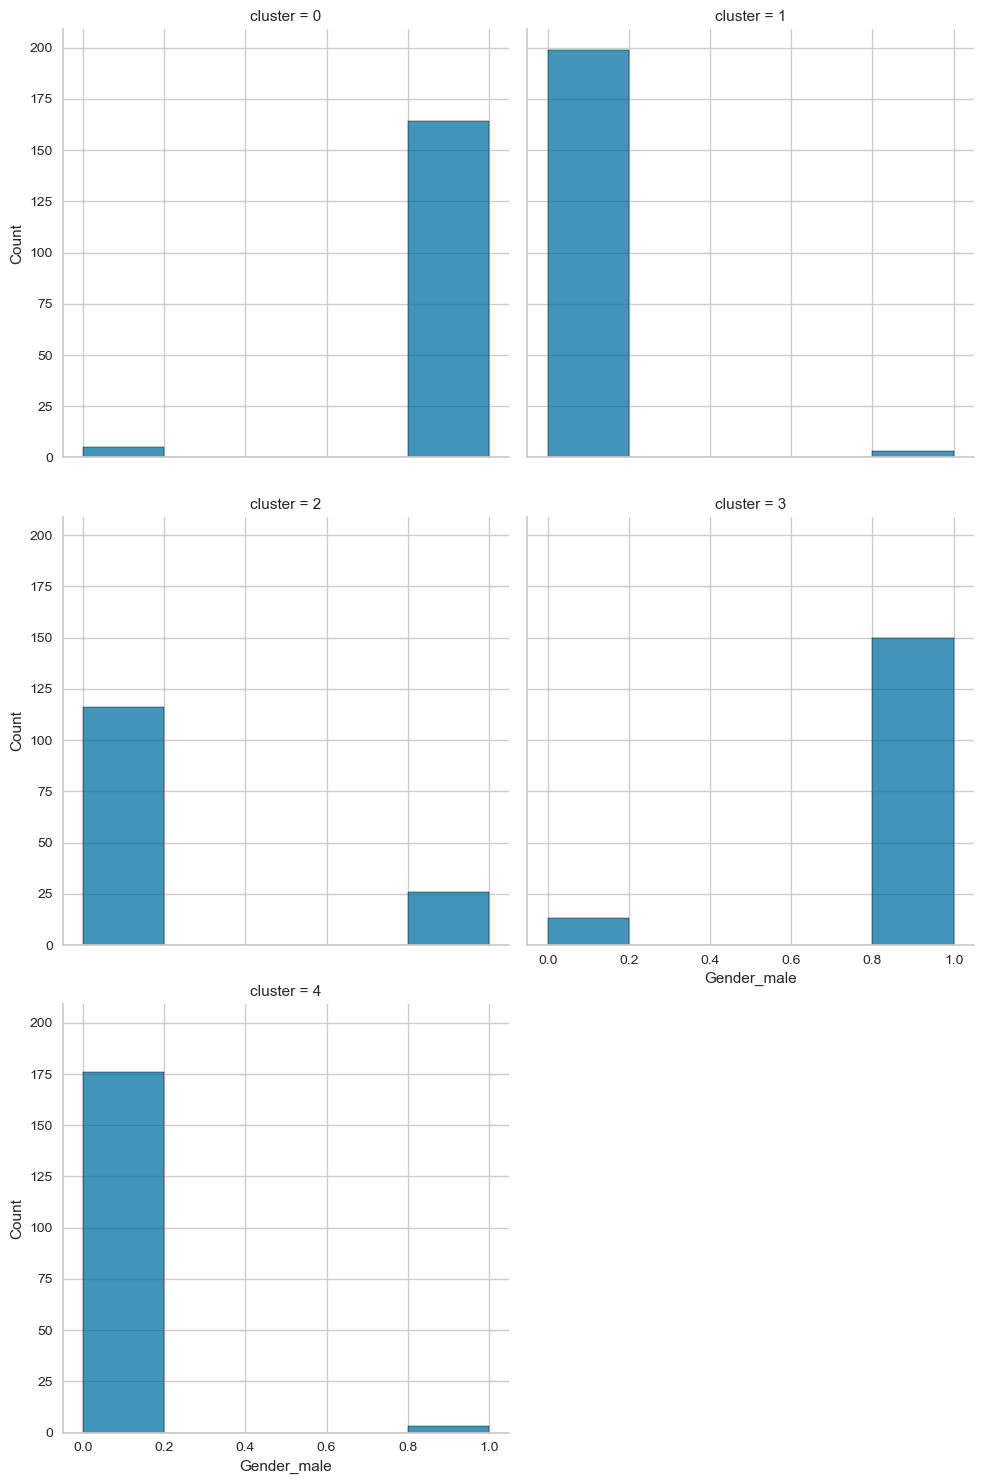

In [18]:
# Male
plt.figure(figsize=(8,4))
print("Male")
sns.displot(data=df, x="Gender_male", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [23]:
dfrom = df[['Gender_male', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

        Gender_male                   
              count unique    top freq
cluster                               
0               169      2   True  164
1               202      2  False  199
2               142      2  False  116
3               163      2   True  150
4               179      2  False  176


### Age

Age


<Figure size 800x400 with 0 Axes>

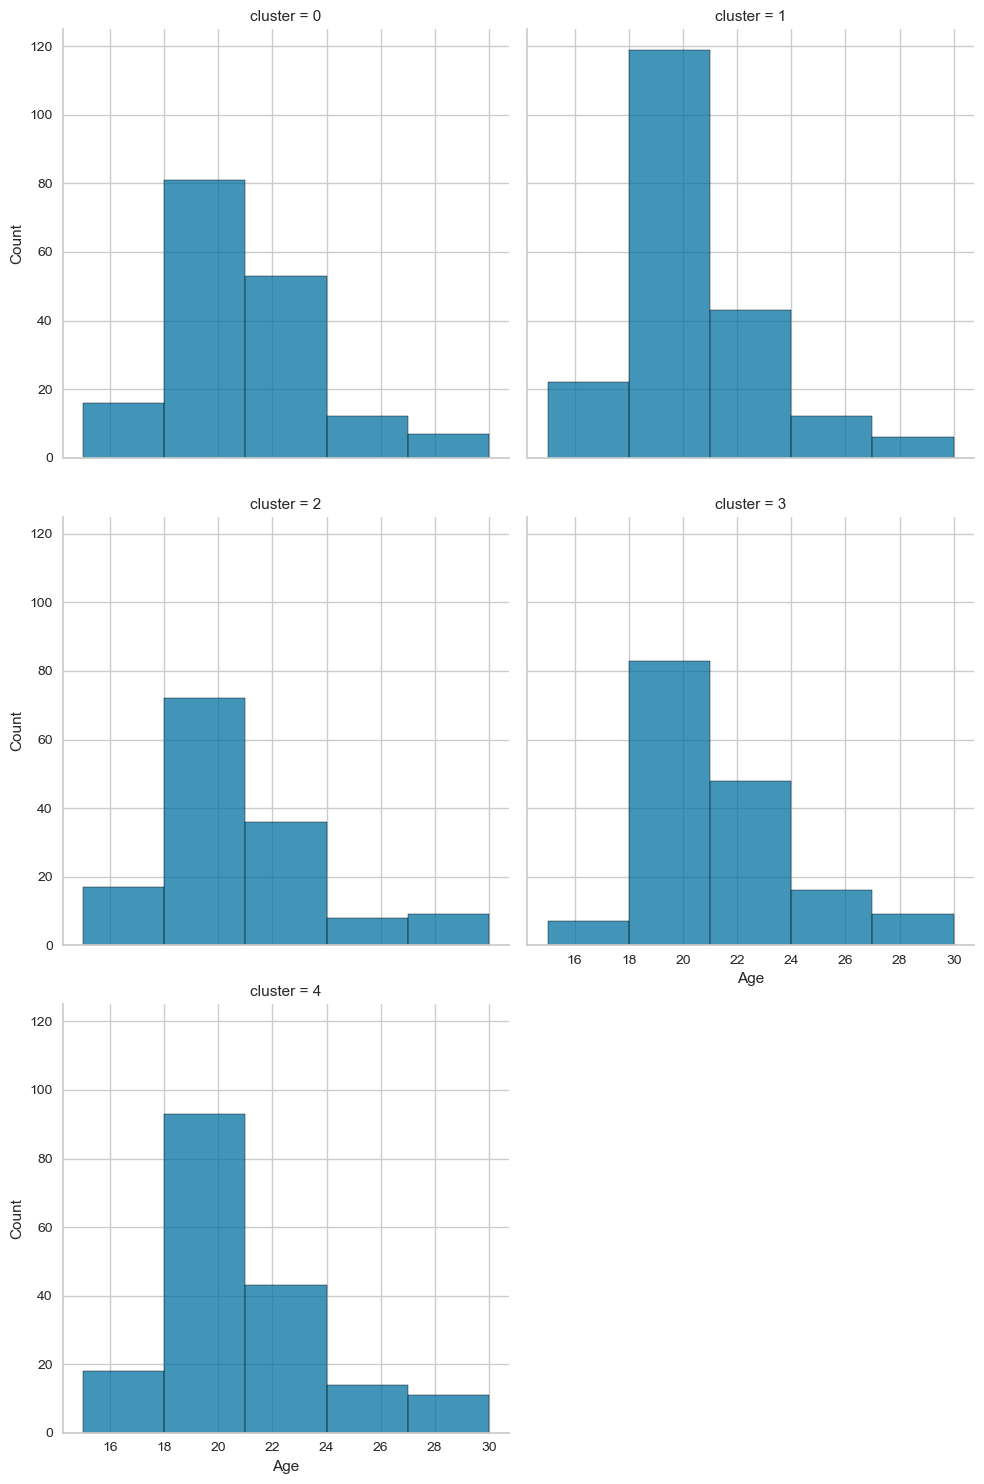

In [21]:
# Age
plt.figure(figsize=(8,4))
print("Age")
sns.displot(data=df, x="Age", bins=5, col='cluster', col_wrap=2, common_bins=True)
plt.show()

In [22]:
dfrom = df[['Age', 'cluster']]

df_desc1 = dfrom.groupby('cluster').describe()
print(df_desc1)

           Age                                                   
         count       mean       std   min   25%   50%   75%   max
cluster                                                          
0        169.0  20.514793  2.641488  15.0  19.0  20.0  22.0  30.0
1        202.0  19.945545  2.559152  15.0  18.0  20.0  21.0  30.0
2        142.0  20.323944  3.033032  15.0  19.0  20.0  21.0  30.0
3        163.0  20.920245  2.795458  16.0  19.0  20.0  22.0  30.0
4        179.0  20.469274  2.924692  15.0  19.0  20.0  22.0  29.0
